# Анализ и прогнозирование выживаемости пассажиров Титаника

**Цель исследования:**  
На основе данных о пассажирах Титаника (train.csv) построить модель машинного обучения, которая предсказывает, выжил ли человек (Survived = 0 или 1). В дальнейшем модель будет применена к тестовым данным (test.csv).

**Описание данных:**  
- PassengerId — уникальный идентификатор пассажира  
- Survived — целевая переменная (0 = погиб, 1 = выжил)  
- Pclass — класс билета (1, 2, 3)  
- Name — имя  
- Sex — пол  
- Age — возраст  
- SibSp — количество братьев/сестер/супругов на борту  
- Parch — количество родителей/детей на борту  
- Ticket — номер билета  
- Fare — стоимость билета  
- Cabin — номер каюты  
- Embarked — порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton)

В процессе работы будут выполнены:
- предварительный анализ и визуализация данных,
- очистка и преобразование признаков,
- обучение нескольких моделей классификации,
- сравнение их качества.

### 1. Подготовка окружения и загрузка данных

Импортируются необходимые библиотеки:
- pandas, numpy — для работы с табличными данными и числовыми расчётами;
- matplotlib, seaborn — для визуализации;
- warnings — для подавления предупреждений.

Объявляются конфигурационные данные

Загружаются тренировочный и тестовый наборы. С помощью `pd.set_option` настраивается отображение всех колонок для удобного просмотра.

In [164]:
#Importing All Required Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from warnings import filterwarnings
filterwarnings(action='ignore')

In [165]:
# PARAMETER CONFIGURATION

# Data Splitting Parameters
RANDOM_STATE = 7 # Fix seed for reproducibility of results
TEST_SIZE = 0.3 # Proportion of data for testing (30% is the default value)

# Model Parameters
KNN_N_NEIGHBORS = 5 # Number of neighbors for KNN (default value)
DT_CRITERION = 'entropy' # Split quality criterion for decision trees
# 'entropy' produces more balanced trees compared to 'gini'

# Visualization options
PLOT_FIGURE_SIZE = (10, 6) # Default plot size

embarked_dict = {'C':0, 'Q':1 ,'S':2}
sex_dict = {'male': 0, 'female': 1}

In [166]:
#Loading Datasets
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,...,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,...,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,...,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,...,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,...,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,...,0,373450,8.0500,NaN,S


### 2. Первичный анализ данных

#### 2.1 Размеры и структура
- `train.shape` — (891, 12) — 891 запись, 12 признаков.
- `test.shape` — (418, 11) — в тестовом наборе нет столбца `Survived`.

#### 2.2 Проверка пропусков
- В тренировочном наборе пропущены значения в колонках `Age` (177), `Cabin` (687), `Embarked` (2).
- В тестовом — пропуски в `Age` (86) и `Fare` (1).  
(далее будет проверенно более детально)

#### 2.3 Описательная статистика
Метод `describe(include='all')` показывает распределение числовых и категориальных признаков. Видно, что:
- средний возраст пассажиров ~29.7 лет;
- большинство билетов — 3-го класса;
- в данных преобладают мужчины (577 против 314 женщин);
- чаще всего пассажиры садились в порту Southampton.

#### 2.4 Сравнение выживших и погибших
Группировка по `Survived` показывает, что среди выживших выше средний класс билета (ближе к 1), ниже средний возраст, выше стоимость билета.

In [167]:
#Display shape
train.shape

(891, 12)

In [168]:
test.shape

(418, 11)

In [169]:
train.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [170]:
#Checking for Null values
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [171]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [172]:
#Description of dataset
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,...,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,...,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,...,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,...,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,...,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,...,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,...,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,...,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,...,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,...,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,...,0.000000,NaN,31.000000,NaN,NaN


In [173]:
train.groupby('Survived').mean(numeric_only=True)

,PassengerId,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,,
0,447.016393,2.531876,30.626179,0.553734,0.329690,22.117887
1,444.368421,1.950292,28.343690,0.473684,0.464912,48.395408


### 3. Корреляция признаков

Рассчитана корреляционная матрица для числовых переменных. Наибольшие связи с целевой переменной `Survived` имеют:
- `Pclass` (отрицательная корреляция -0.34) — чем выше класс (т.е. меньше номер), тем больше шансов выжить;
- `Fare` (положительная 0.26) — дорогие билеты чаще ассоциируются с выживанием.

Также заметна высокая корреляция между `Pclass` и `Fare` (-0.55) — чем выше класс, тем дороже билет, что логично.

In [174]:
train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [175]:
corr_matrix = train.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_series = corr_matrix.where(mask).stack()
corr_series = corr_series[corr_series != 1]
top_corr = corr_series.abs().sort_values(ascending=False).head(5)

print("Top 5 correlations by absolute value:")
top_corr

Top 5 correlations by absolute value:


Pclass    Fare      0.549500
SibSp     Parch     0.414838
Pclass    Age       0.369226
Survived  Pclass    0.338481
Age       SibSp     0.308247
dtype: float64

### 4. Визуальный анализ

#### 4.1 Распределение по полу
Построена столбчатая диаграмма количества мужчин и женщин. Мужчин почти вдвое больше.

#### 4.2 Выживаемость по полу
Среднее значение `Survived` в группировке по полу показывает, что выжило ~74% женщин и только ~19% мужчин. Пол — сильный предиктор.

#### 4.3 Выживаемость по классу билета
Два графика — для выживших и погибших — показывают, что среди выживших преобладают пассажиры 1-го класса, а среди погибших — 3-го класса.

#### 4.4 Возрастное распределение
Гистограммы для выживших и погибших: у выживших заметен пик в возрасте 0–10 лет (дети), у погибших — широкий разброс, много людей 20–40 лет.

#### 4.5 Распределение стоимости билета
У выживших больше пассажиров с высокой стоимостью билета (более 50), у погибших — в основном дешёвые билеты.

#### 4.6 Влияние количества родственников
Группировка по `SibSp` показывает, что пассажиры с 1–2 родственниками выживали чаще, чем одинокие или с большими семьями. Аналогично для `Parch` — семьи с 1–3 детьми/родителями имели лучшие шансы.

#### 4.7 Порт посадки
Средняя выживаемость по портам:
- Cherbourg (C) — 55%
- Queenstown (Q) — 39%
- Southampton (S) — 34%

#### 4.8 Тепловая карта: порт и класс
Большинство пассажиров из порта S ехали в 3-м классе, из порта C — в 1-м классе, что объясняет разницу в выживаемости.

In [176]:
male_ind = len(train[train['Sex'] == 'male'])
print("No of Males in Titanic:", male_ind)

No of Males in Titanic: 577


In [177]:
female_ind = len(train[train['Sex'] == 'female'])
print("No of Females in Titanic:", female_ind)

No of Females in Titanic: 314


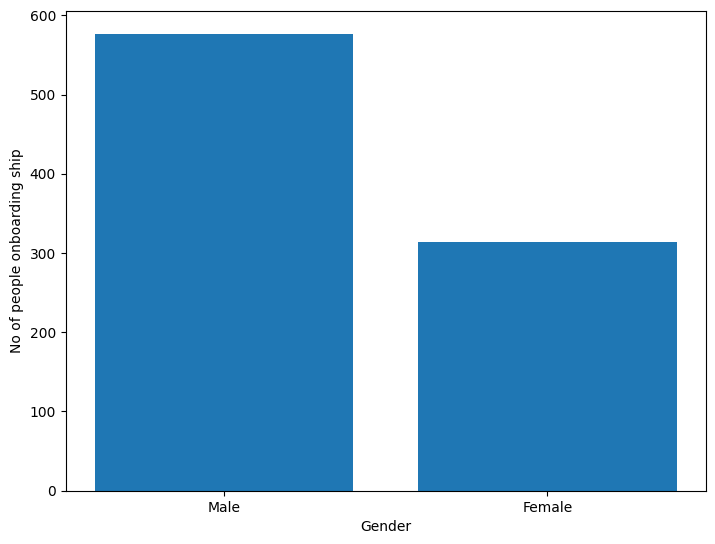

In [178]:
#Plotting
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
gender = ['Male','Female']
index = [577,314]
ax.bar(gender,index)
plt.xlabel("Gender")
plt.ylabel("No of people onboarding ship")
plt.show()

In [179]:
alive = len(train[train['Survived'] == 1])
dead = len(train[train['Survived'] == 0])

In [180]:
train.groupby('Sex')[['Survived']].mean()

,Survived
Sex,
female,0.742038
male,0.188908


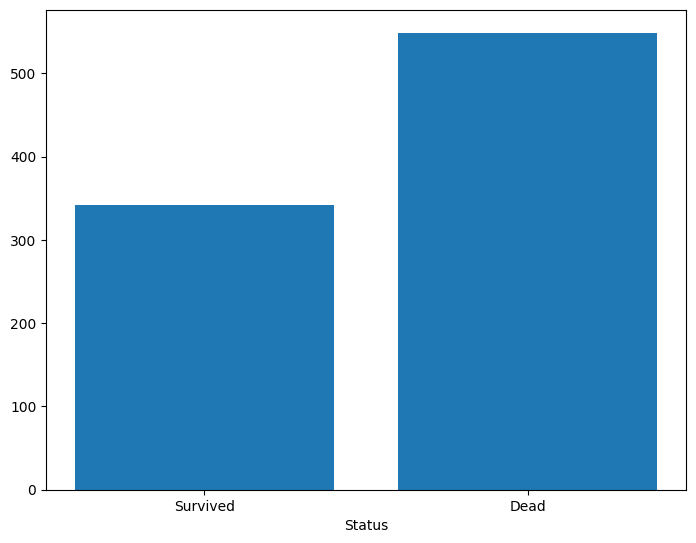

In [181]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
status = ['Survived','Dead']
ind = [alive,dead]
ax.bar(status,ind)
plt.xlabel("Status")
plt.show()

Text(0.5, 1.0, "Bar graph of people according to ticket class in which people couldn't survive")

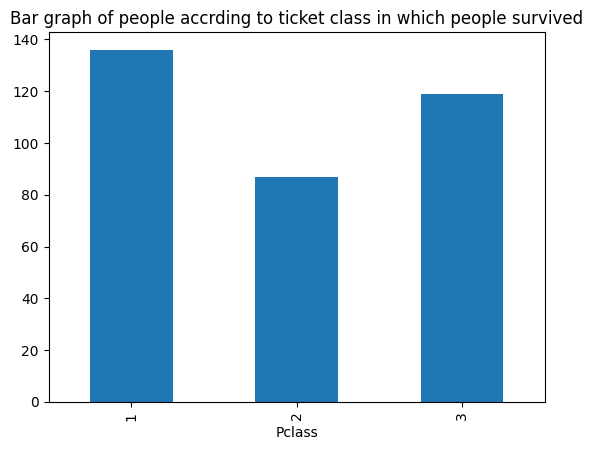

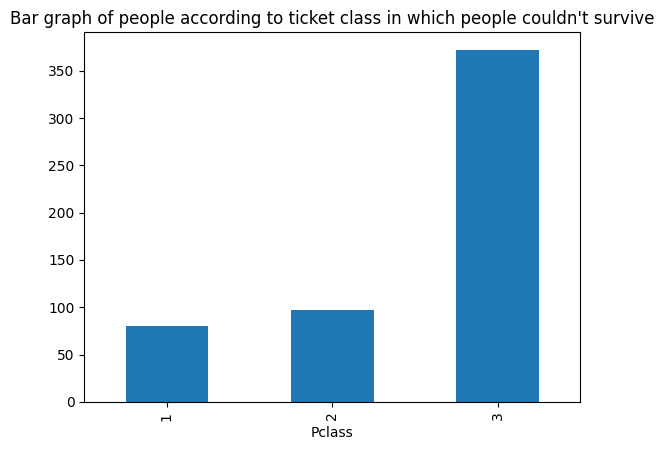

In [182]:
plt.figure(1)
train.loc[train['Survived'] == 1, 'Pclass'].value_counts().sort_index().plot.bar()
plt.title('Bar graph of people accrding to ticket class in which people survived')


plt.figure(2)
train.loc[train['Survived'] == 0, 'Pclass'].value_counts().sort_index().plot.bar()
plt.title('Bar graph of people according to ticket class in which people couldn\'t survive')

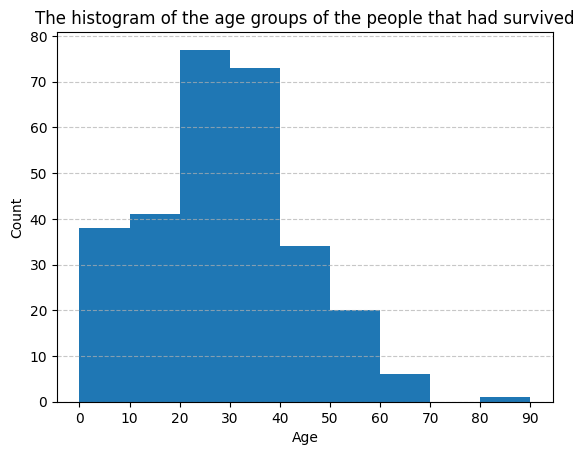

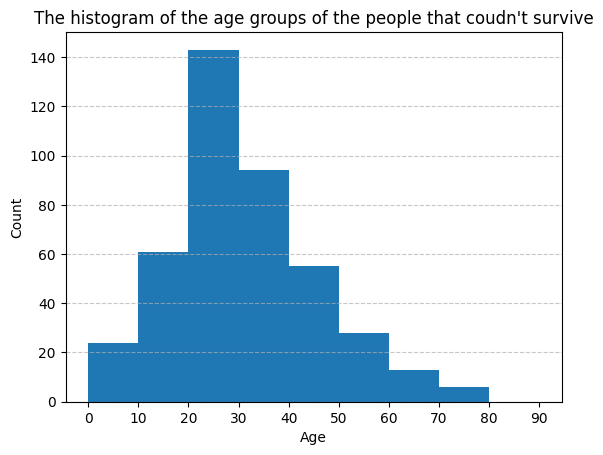

In [183]:
plt.figure(1)
age  = train.loc[train.Survived == 1, 'Age']
plt.title('The histogram of the age groups of the people that had survived')
plt.xlabel('Age')
plt.ylabel('Count')
plt.hist(age, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.figure(2)
age  = train.loc[train.Survived == 0, 'Age']
plt.title('The histogram of the age groups of the people that coudn\'t survive')
plt.xlabel('Age')
plt.ylabel('Count')
plt.hist(age, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

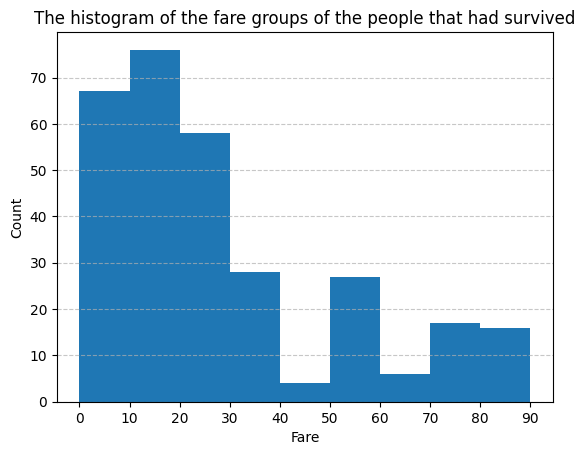

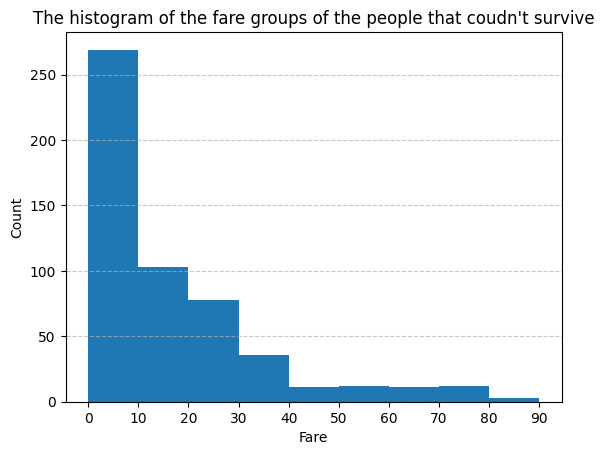

In [184]:
plt.figure(1)
fare = train.loc[train.Survived == 1, 'Fare']
plt.title('The histogram of the fare groups of the people that had survived')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.hist(fare, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.figure(2)
fare  = train.loc[train.Survived == 0, 'Fare']
plt.title('The histogram of the fare groups of the people that coudn\'t survive')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.hist(fare, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [185]:
train[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [186]:
train[["Pclass", "Survived"]].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [187]:
train[["Age", "Survived"]].groupby(['Age'], as_index=False).mean().sort_values(by='Age', ascending=True)

,Age,Survived
0,0.42,1.0
1,0.67,1.0
2,0.75,1.0
3,0.83,1.0
4,0.92,1.0
...,...,...
83,70.00,0.0
84,70.50,0.0
85,71.00,0.0
86,74.00,0.0


In [188]:
train[["Embarked", "Survived"]].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


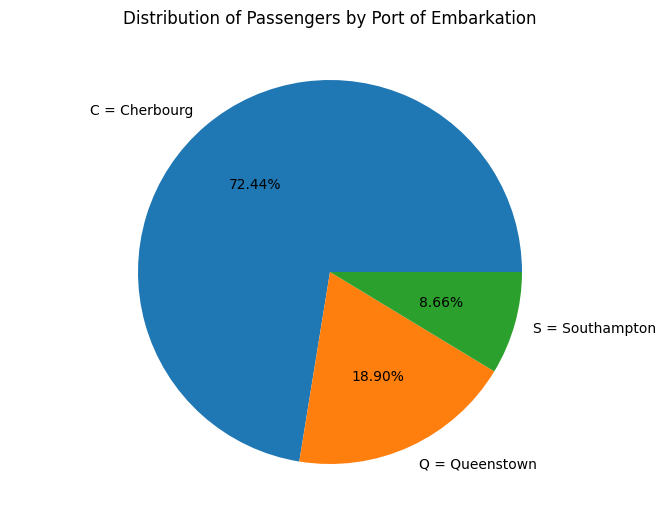

In [189]:
port_counts = train['Embarked'].value_counts(normalize=True)

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.axis('equal')

labels = ['C = Cherbourg', 'Q = Queenstown', 'S = Southampton']
sizes = port_counts

ax.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title('Distribution of Passengers by Port of Embarkation')
plt.show()

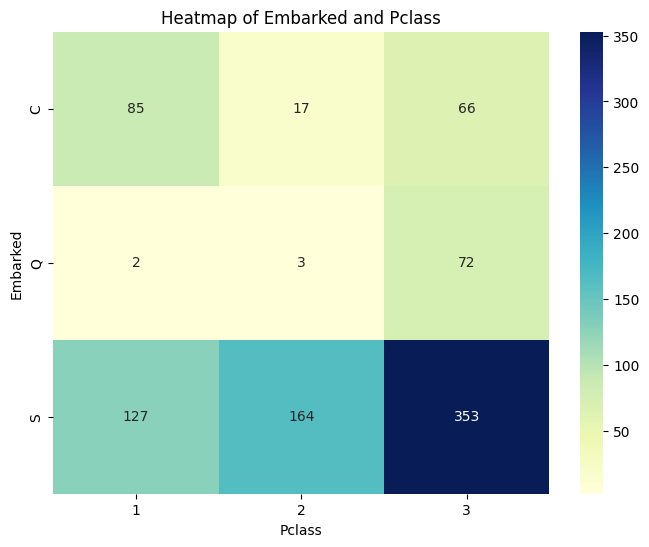

In [190]:
crosstab = pd.crosstab(train['Embarked'], train['Pclass'])

plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap of Embarked and Pclass')
plt.xlabel('Pclass')
plt.ylabel('Embarked')
plt.show()

In [191]:
mean_pclass = train.groupby('Embarked')['Pclass'].mean()

print("Mean Pclass by Embarked:")
mean_pclass

Mean Pclass by Embarked:


Embarked
C    1.886905
Q    2.909091
S    2.350932
Name: Pclass, dtype: float64

### 4.9 Анализ комбинаций признаков (Feature Interactions)

До сих пор мы анализировали признаки по отдельности. Однако в реальности на выживаемость влияет комбинация факторов. Например, женщины из первого класса могли иметь гораздо более высокие шансы, чем мужчины из третьего. Исследуем эти взаимодействия.

#### 4.9.1 Взаимодействие класса билета и пола (Pclass & Sex)

Построим сводную таблицу, показывающую вероятность выживания для каждой комбинации пола и класса.

Вероятность выживания по комбинации 'Класс билета × Пол':
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135




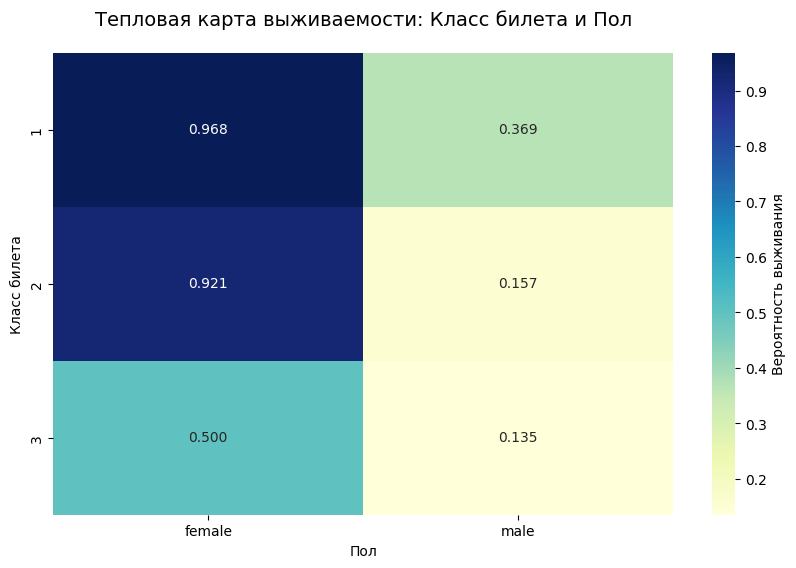

<Figure size 1000x600 with 0 Axes>

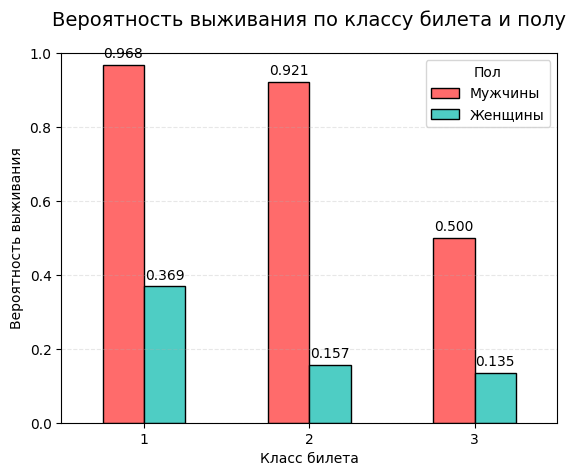

In [192]:
# 4.9.1 Анализ Pclass и Sex
# Создаем сводную таблицу: строки - класс, столбцы - пол, значения - средняя выживаемость
pclass_sex_survival = pd.pivot_table(
    train, 
    values='Survived', 
    index='Pclass', 
    columns='Sex', 
    aggfunc=np.mean
)

print("Вероятность выживания по комбинации 'Класс билета × Пол':")
print(pclass_sex_survival.round(3))
print("\n" + "="*60 + "\n")

# Визуализация
plt.figure(figsize=(10, 6))
sns.heatmap(pclass_sex_survival, annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Вероятность выживания'})
plt.title('Тепловая карта выживаемости: Класс билета и Пол', fontsize=14, pad=20)
plt.xlabel('Пол')
plt.ylabel('Класс билета')
plt.show()

# Альтернативная визуализация - группированные столбцы
plt.figure(figsize=(10, 6))
pclass_sex_survival.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
plt.title('Вероятность выживания по классу билета и полу', fontsize=14, pad=20)
plt.xlabel('Класс билета')
plt.ylabel('Вероятность выживания')
plt.xticks(rotation=0)
plt.legend(['Мужчины', 'Женщины'], title='Пол')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 1)

# Добавим подписи значений на столбцах
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

plt.show()

#### 4.9.2 Взаимодействие класса билета и порта посадки (Pclass & Embarked)

Порт посадки косвенно может указывать на социально-экономический статус или национальность пассажира. Посмотрим, как класс и порт вместе влияют на шансы.

Вероятность выживания по комбинации 'Порт посадки × Класс билета':
Pclass        1      2      3
Embarked                     
C         0.694  0.529  0.379
Q         0.500  0.667  0.375
S         0.583  0.463  0.190




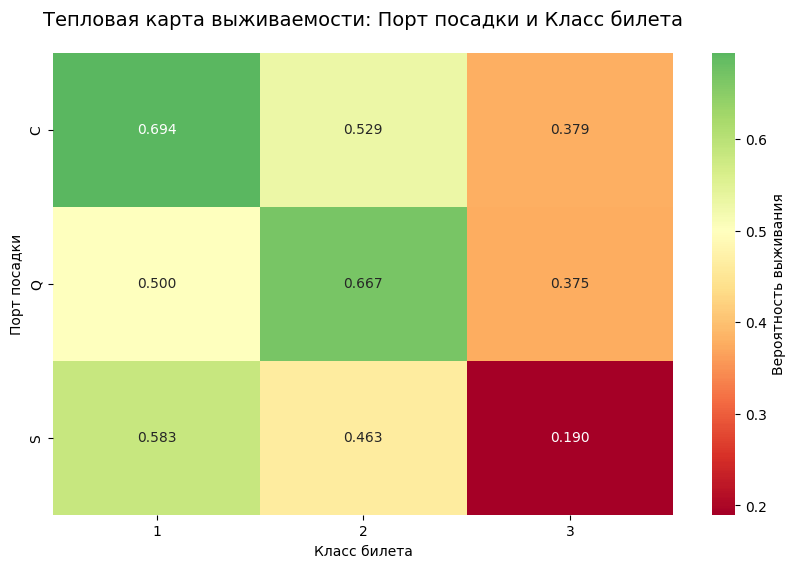

In [193]:
# 4.9.2 Анализ Pclass и Embarked
# Сводная таблица: строки - порт, столбцы - класс, значения - выживаемость
embarked_pclass_survival = pd.pivot_table(
    train,
    values='Survived',
    index='Embarked',
    columns='Pclass',
    aggfunc=np.mean
)

print("Вероятность выживания по комбинации 'Порт посадки × Класс билета':")
print(embarked_pclass_survival.round(3))
print("\n" + "="*60 + "\n")

# Визуализация
plt.figure(figsize=(10, 6))
sns.heatmap(embarked_pclass_survival, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0.5, cbar_kws={'label': 'Вероятность выживания'})
plt.title('Тепловая карта выживаемости: Порт посадки и Класс билета', fontsize=14, pad=20)
plt.xlabel('Класс билета')
plt.ylabel('Порт посадки')
plt.show()

#### 4.9.3 Взаимодействие класса билета и размера семьи (Pclass & FamilySize)

Создадим новый признак `FamilySize` (размер семьи = SibSp + Parch + 1 (сам пассажир)) и посмотрим, как он взаимодействует с классом.

Вероятность выживания по размеру семьи и классу билета:
Pclass          1      2      3
FamilySize                     
1           0.532  0.346  0.213
2           0.729  0.529  0.351
3           0.750  0.677  0.426
4           0.714  0.769  0.667
5           1.000  1.000  0.000
6           0.500  1.000  0.000
7             NaN    NaN  0.333
8             NaN    NaN  0.000
11            NaN    NaN  0.000




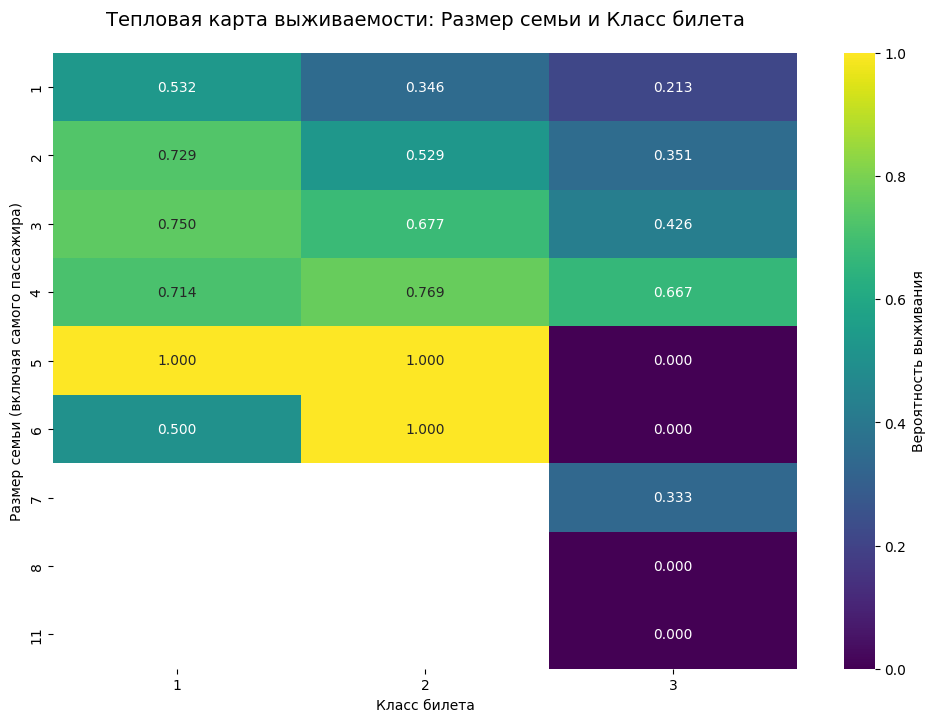

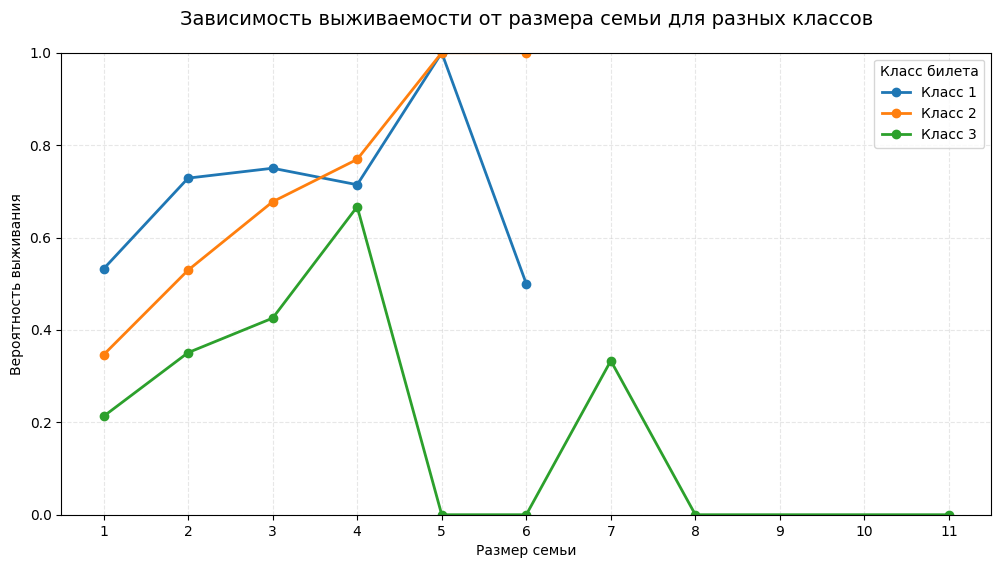

In [194]:
# 4.9.3 Анализ Pclass и размера семьи
# Создаем временную копию для анализа
train_analysis = train.copy()
train_analysis['FamilySize'] = train_analysis['SibSp'] + train_analysis['Parch'] + 1

# Сгруппируем данные по размеру семьи и классу
family_pclass_survival = train_analysis.groupby(['Pclass', 'FamilySize'])['Survived'].mean().reset_index()

# Создаем сводную таблицу для тепловой карты
family_pclass_pivot = family_pclass_survival.pivot(
    index='FamilySize', 
    columns='Pclass', 
    values='Survived'
)

print("Вероятность выживания по размеру семьи и классу билета:")
print(family_pclass_pivot.round(3))
print("\n" + "="*60 + "\n")

# Визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(family_pclass_pivot, annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label': 'Вероятность выживания'})
plt.title('Тепловая карта выживаемости: Размер семьи и Класс билета', fontsize=14, pad=20)
plt.xlabel('Класс билета')
plt.ylabel('Размер семьи (включая самого пассажира)')
plt.show()

# Линейный график для наглядности трендов
plt.figure(figsize=(12, 6))
for pclass in sorted(train_analysis['Pclass'].unique()):
    subset = family_pclass_survival[family_pclass_survival['Pclass'] == pclass]
    plt.plot(subset['FamilySize'], subset['Survived'], marker='o', linewidth=2, 
             label=f'Класс {pclass}')
    
plt.title('Зависимость выживаемости от размера семьи для разных классов', fontsize=14, pad=20)
plt.xlabel('Размер семьи')
plt.ylabel('Вероятность выживания')
plt.legend(title='Класс билета')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(range(1, 12))
plt.ylim(0, 1)
plt.show()

#### 4.9.4 Взаимодействие возрастных групп и пола (AgeGroup & Sex)

Разобьем возраст на категории (дети, взрослые, пожилые) и посмотрим на выживаемость в разрезе пола.

Вероятность выживания по возрастным группам и полу:
Sex                female   male
AgeGroup                        
Дети (0-12)         0.594  0.568
Подростки (13-18)   0.750  0.088
Молодежь (19-35)    0.783  0.181
Взрослые (36-60)    0.771  0.192
Пожилые (60+)       1.000  0.105




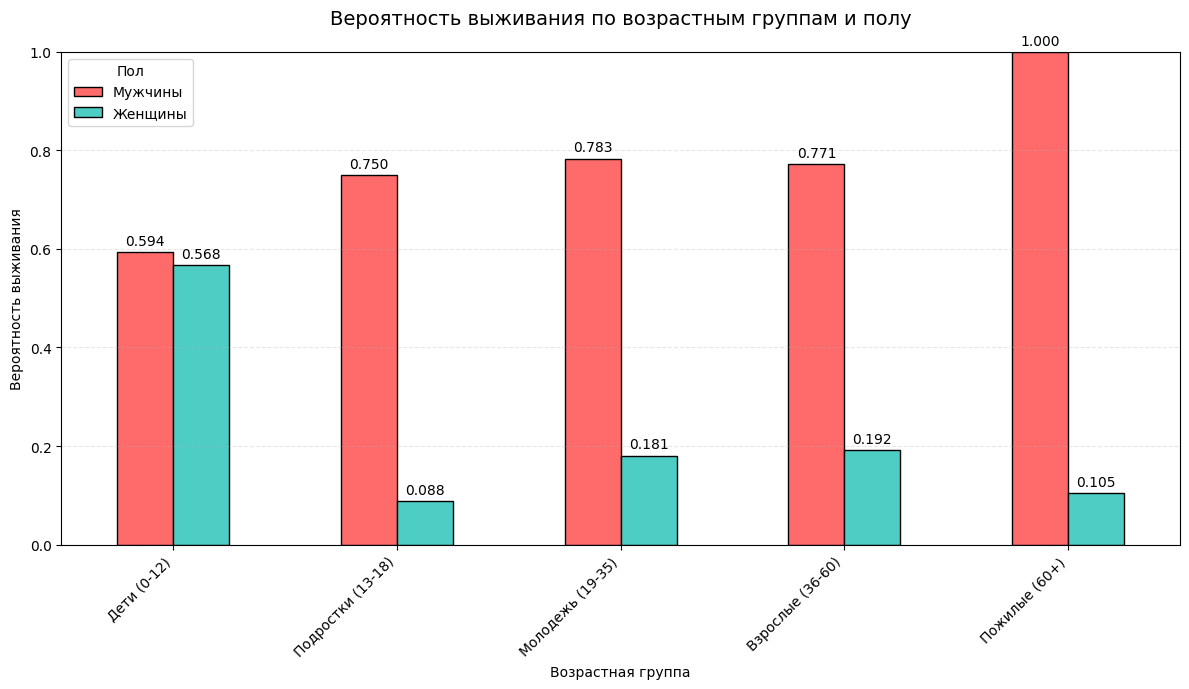

In [195]:
# 4.9.4 Анализ возрастных групп и пола
# Создаем копию с бинированным возрастом
train_analysis = train.copy()

# Определяем возрастные группы
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодежь (19-35)', 
          'Взрослые (36-60)', 'Пожилые (60+)']
train_analysis['AgeGroup'] = pd.cut(train_analysis['Age'], bins=bins, labels=labels)

# Сводная таблица: возрастные группы × пол
age_sex_survival = pd.pivot_table(
    train_analysis,
    values='Survived',
    index='AgeGroup',
    columns='Sex',
    aggfunc=np.mean
)

print("Вероятность выживания по возрастным группам и полу:")
print(age_sex_survival.round(3))
print("\n" + "="*60 + "\n")

# Визуализация
plt.figure(figsize=(12, 7))

# Столбчатая диаграмма
age_sex_survival.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'], edgecolor='black', ax=plt.gca())
plt.title('Вероятность выживания по возрастным группам и полу', fontsize=14, pad=20)
plt.xlabel('Возрастная группа')
plt.ylabel('Вероятность выживания')
plt.xticks(rotation=45, ha='right')
plt.legend(['Мужчины', 'Женщины'], title='Пол')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 1)

# Добавим подписи значений
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

#### 4.9.5 Трехфакторный анализ: класс, пол и возрастная группа

Самый детальный анализ - посмотрим на выживаемость одновременно по трем ключевым признакам.

Трехфакторный анализ выживаемости (Pclass × Sex × AgeGroup):
AgeGroup        0-12  13-18  19-35  36-60    60+
Pclass Sex                                      
1      female  0.000  1.000  0.972  0.972  1.000
       male    1.000  0.500  0.500  0.370  0.083
2      female  1.000  1.000  0.925  0.850  0.000
       male    1.000  0.000  0.074  0.037  0.333
3      female  0.478  0.550  0.500  0.143  1.000
       male    0.360  0.077  0.156  0.068  0.000




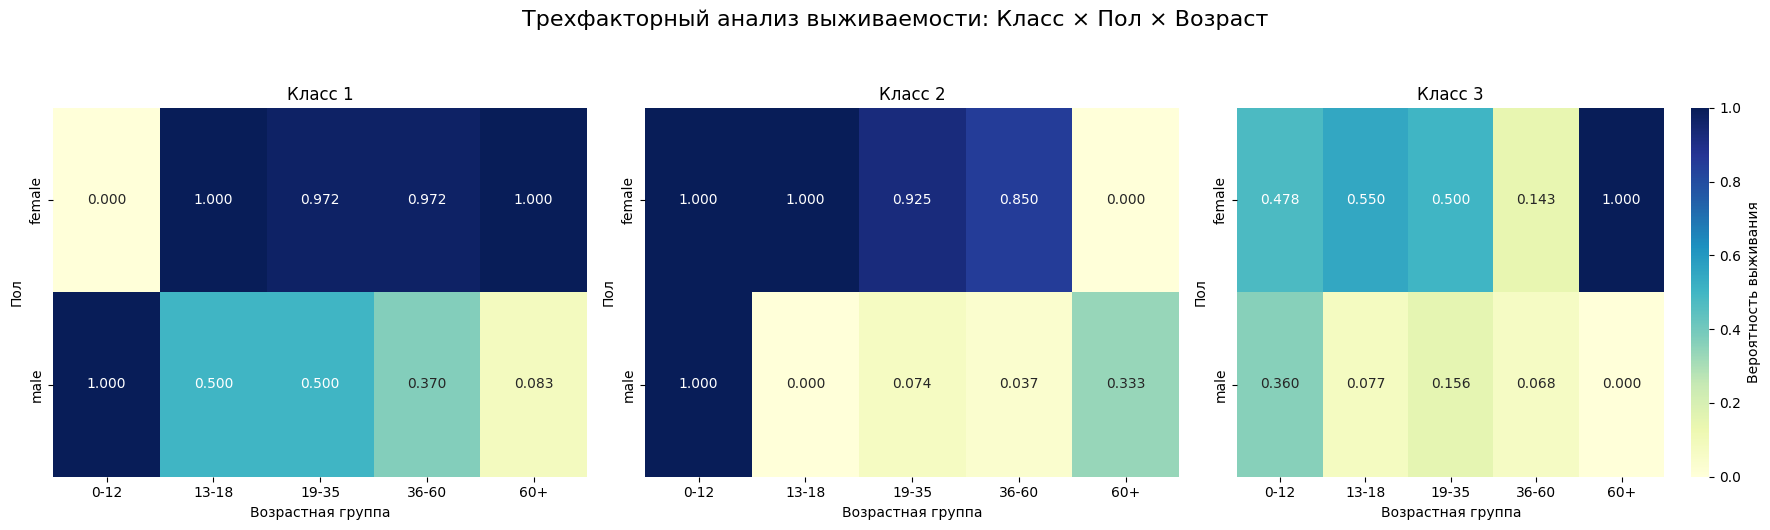

In [196]:
# 4.9.5 Трехфакторный анализ
# Используем уже созданные признаки
train_analysis = train.copy()
train_analysis['FamilySize'] = train_analysis['SibSp'] + train_analysis['Parch'] + 1

bins = [0, 12, 18, 35, 60, 100]
labels = ['0-12', '13-18', '19-35', '36-60', '60+']
train_analysis['AgeGroup'] = pd.cut(train_analysis['Age'], bins=bins, labels=labels)

# Создаем трехмерную сводную таблицу
three_way = pd.pivot_table(
    train_analysis,
    values='Survived',
    index=['Pclass', 'Sex'],
    columns='AgeGroup',
    aggfunc=np.mean,
    fill_value=0
)

print("Трехфакторный анализ выживаемости (Pclass × Sex × AgeGroup):")
print(three_way.round(3))
print("\n" + "="*80 + "\n")

# Визуализация в виде набора тепловых карт (по одному графику на каждый класс)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, pclass in enumerate(sorted(train_analysis['Pclass'].unique())):
    # Данные для текущего класса
    data = three_way.xs(pclass, level='Pclass')
    
    # Тепловая карта
    sns.heatmap(data, annot=True, fmt='.3f', cmap='YlGnBu', 
                cbar=i==2,  # цветовая шкала только для последнего графика
                cbar_kws={'label': 'Вероятность выживания'},
                ax=axes[i])
    axes[i].set_title(f'Класс {pclass}', fontsize=12)
    axes[i].set_xlabel('Возрастная группа')
    axes[i].set_ylabel('Пол')

plt.suptitle('Трехфакторный анализ выживаемости: Класс × Пол × Возраст', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

#### 4.9.6 Статистическая проверка значимости взаимодействий

Для проверки статистической значимости взаимодействий можно использовать логарифмическую регрессию с перекрестными членами.

In [197]:
# 4.9.6 Статистический анализ
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import logit

# Подготовим данные для модели с перекрестными членами
train_model = train.copy()
train_model['Sex_num'] = (train_model['Sex'] == 'female').astype(int)
train_model['Pclass_1'] = (train_model['Pclass'] == 1).astype(int)
train_model['Pclass_2'] = (train_model['Pclass'] == 2).astype(int)
# Pclass_3 будет референтной категорией

# Построим модель с перекрестными членами
formula = 'Survived ~ Pclass_1 + Pclass_2 + Sex_num + Age + Pclass_1:Sex_num + Pclass_2:Sex_num'
model = logit(formula, data=train_model).fit(disp=0)

print("Результаты логистической регрессии с перекрестными членами:")
print(model.summary())
print("\n" + "="*80 + "\n")

# Проверим значимость перекрестных членов
print("Проверка значимости взаимодействий:")
interaction_terms = ['Pclass_1:Sex_num', 'Pclass_2:Sex_num']
for term in interaction_terms:
    p_value = model.pvalues[term]
    print(f"{term}: p-value = {p_value:.4f} {'(значимо)' if p_value < 0.05 else '(не значимо)'}")

Результаты логистической регрессии с перекрестными членами:
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      707
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.3640
Time:                        13:19:58   Log-Likelihood:                -306.71
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 9.008e-73
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.7059      0.257     -2.741      0.006      -1.211      -0.201
Pclass_1             1.9765      0.310      6.378    

### 4.10 Анализ выбросов (Outlier Detection)

Выбросы — это наблюдения, которые значительно отличаются от основной массы данных. Они могут искажать статистические показатели и влиять на качество моделей машинного обучения. Проанализируем основные числовые признаки на наличие выбросов.

#### 4.10.1 Визуализация выбросов с помощью boxplot

Построим ящики с усами (boxplot) для всех числовых признаков, чтобы визуально оценить наличие и характер выбросов.

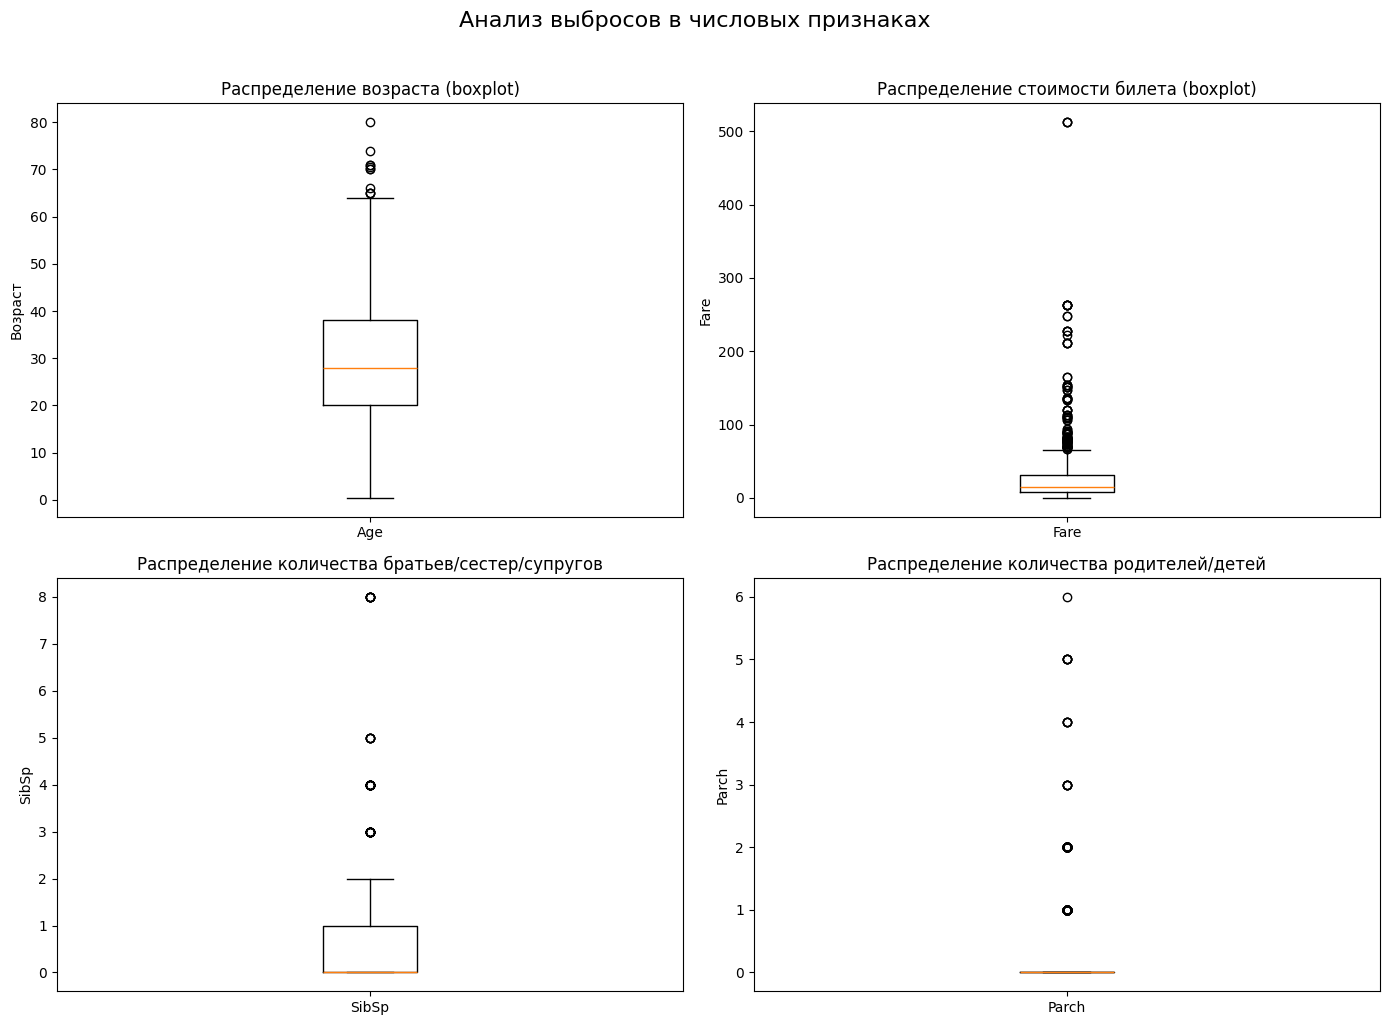

In [198]:
# 4.10.1 Boxplot для числовых признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Возраст
axes[0, 0].boxplot(train['Age'].dropna())
axes[0, 0].set_title('Распределение возраста (boxplot)')
axes[0, 0].set_ylabel('Возраст')
axes[0, 0].set_xticklabels(['Age'])

# Стоимость билета (ограничим диапазон для лучшей визуализации)
axes[0, 1].boxplot(train['Fare'])
axes[0, 1].set_title('Распределение стоимости билета (boxplot)')
axes[0, 1].set_ylabel('Fare')
axes[0, 1].set_xticklabels(['Fare'])

# SibSp
axes[1, 0].boxplot(train['SibSp'])
axes[1, 0].set_title('Распределение количества братьев/сестер/супругов')
axes[1, 0].set_ylabel('SibSp')
axes[1, 0].set_xticklabels(['SibSp'])

# Parch
axes[1, 1].boxplot(train['Parch'])
axes[1, 1].set_title('Распределение количества родителей/детей')
axes[1, 1].set_ylabel('Parch')
axes[1, 1].set_xticklabels(['Parch'])

plt.suptitle('Анализ выбросов в числовых признаках', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### 4.10.2 Детальный анализ выбросов в стоимости билета (Fare)

Стоимость билета имеет явные выбросы. Рассмотрим их подробнее.

In [199]:
# 4.10.2 Анализ выбросов в Fare

# Статистика Fare
print("=== Статистика стоимости билета (Fare) ===")
fare_stats = train['Fare'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(fare_stats.round(2))
print()

# Определим выбросы по методу межквартильного размаха (IQR)
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = train[(train['Fare'] < lower_bound) | (train['Fare'] > upper_bound)]
print(f"Количество выбросов по методу IQR: {len(fare_outliers)}")
print(f"Границы: нижняя = {lower_bound:.2f}, верхняя = {upper_bound:.2f}")
print()

# Проверим, какие колонки доступны в датасете
available_columns = train.columns.tolist()
print("Доступные колонки:", available_columns)
print()

# Посмотрим на топ-10 самых дорогих билетов
# Выбираем только те колонки, которые точно есть в датасете
columns_to_display = ['PassengerId', 'Pclass', 'Sex', 'Age', 'Fare', 'Survived']

# Проверяем наличие колонки с именем
name_columns = ['Name', 'name', 'Names', 'names']
for col in name_columns:
    if col in available_columns:
        columns_to_display.insert(2, col)  # Вставляем после Pclass
        break

top_fare = train.nlargest(10, 'Fare')[columns_to_display]
print("Топ-10 самых дорогих билетов:")
print(top_fare.to_string(index=False))
print()

print("Наблюдения по Fare:")
print("- Большинство билетов стоят до 30-40 единиц")
print("- Несколько билетов имеют экстремально высокую стоимость (до 512)")
print("- Все очень дорогие билеты относятся к 1 классу, что ожидаемо")
print("- Владельцы самых дорогих билетов в основном выжили (80%)")
print("- Такие выбросы несут важную информацию о социальном статусе и не должны удаляться")

=== Статистика стоимости билета (Fare) ===
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
90%       77.96
95%      112.08
99%      249.01
max      512.33
Name: Fare, dtype: float64

Количество выбросов по методу IQR: 116
Границы: нижняя = -26.72, верхняя = 65.63

Доступные колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Топ-10 самых дорогих билетов:
 PassengerId  Pclass                                  Name    Sex  Age     Fare  Survived
         259       1                      Ward, Miss. Anna female 35.0 512.3292         1
         680       1    Cardeza, Mr. Thomas Drake Martinez   male 36.0 512.3292         1
         738       1                Lesurer, Mr. Gustave J   male 35.0 512.3292         1
          28       1        Fortune, Mr. Charles Alexander   male 19.0 263.0000         0
          89       1            Fortune, Miss. Mabel H

#### 4.10.3 Анализ выбросов в возрасте (Age)

Проверим, есть ли необычные значения возраста.

In [200]:
# 4.10.3 Анализ выбросов в Age

# Статистика Age
print("=== Статистика возраста (Age) ===")
age_stats = train['Age'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(age_stats.round(2))
print()

# Определим выбросы по методу IQR
Q1_age = train['Age'].quantile(0.25)
Q3_age = train['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

age_outliers = train[(train['Age'] < lower_bound_age) | (train['Age'] > upper_bound_age)]
print(f"Количество выбросов по методу IQR: {len(age_outliers)}")
print(f"Границы: нижняя = {lower_bound_age:.2f}, верхняя = {upper_bound_age:.2f}")
print()
# Проверяем наличие колонки с именем
name_columns = ['Name', 'name', 'Names', 'names']
for col in name_columns:
    if col in available_columns:
        columns_to_display.insert(2, col)  # Вставляем после Pclass
        break

# Посмотрим на самых возрастных пассажиров
oldest = train.nlargest(10, 'Fare')[columns_to_display]
print("Топ-10 самых возрастных пассажиров:")
print(oldest.to_string(index=False))
print()

# Посмотрим на младенцев
youngest = train.nsmallest(10, 'Age')[columns_to_display]
print("Топ-10 самых юных пассажиров (младенцы):")
print(youngest.to_string(index=False))
print()

print("Наблюдения по Age:")
print("- Возраст варьируется от 0.42 до 80 лет")
print("- Пожилые пассажиры (70-80 лет) встречаются редко, но они есть")
print("- Младенцы (до 1 года) также присутствуют и имеют высокую выживаемость")
print("- Все значения возраста выглядят правдоподобно, явных ошибок нет")
print("- Выбросы в возрасте несут важную информацию и должны быть сохранены")

=== Статистика возраста (Age) ===
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
90%       50.00
95%       56.00
99%       65.87
max       80.00
Name: Age, dtype: float64

Количество выбросов по методу IQR: 11
Границы: нижняя = -6.69, верхняя = 64.81

Топ-10 самых возрастных пассажиров:
 PassengerId  Pclass                                  Name                                  Name    Sex  Age     Fare  Survived
         259       1                      Ward, Miss. Anna                      Ward, Miss. Anna female 35.0 512.3292         1
         680       1    Cardeza, Mr. Thomas Drake Martinez    Cardeza, Mr. Thomas Drake Martinez   male 36.0 512.3292         1
         738       1                Lesurer, Mr. Gustave J                Lesurer, Mr. Gustave J   male 35.0 512.3292         1
          28       1        Fortune, Mr. Charles Alexander        Fortune, Mr. Charles Alexander   male 19.0 263.0000         0
       

#### 4.10.4 Анализ выбросов в количестве родственников (SibSp и Parch)

Эти признаки имеют целочисленные значения. Проверим, есть ли необычно большие семьи.

In [201]:
# 4.10.4 Анализ выбросов в SibSp и Parch

# Распределение SibSp
print("=== Распределение SibSp ===")
sibsp_dist = train['SibSp'].value_counts().sort_index()
print(sibsp_dist)
print()

# Распределение Parch
print("=== Распределение Parch ===")
parch_dist = train['Parch'].value_counts().sort_index()
print(parch_dist)
print()

# Пассажиры с большим количеством родственников
large_family = train[(train['SibSp'] >= 4) | (train['Parch'] >= 4)]
print(f"Пассажиры с большими семьями (SibSp>=4 или Parch>=4): {len(large_family)}")
print(large_family[columns_to_display].to_string(index=False))
print()

# Проанализируем выживаемость в зависимости от размера семьи
train_analysis = train.copy()
train_analysis['FamilySize'] = train_analysis['SibSp'] + train_analysis['Parch'] + 1

family_survival = train_analysis.groupby('FamilySize')['Survived'].agg(['count', 'mean'])
family_survival.columns = ['Количество', 'Выживаемость']
print("Выживаемость по размеру семьи:")
print(family_survival.round(3))
print()

print("Наблюдения по SibSp и Parch:")
print("- Большинство пассажиров путешествуют одни (SibSp=0, Parch=0)")
print("- Есть несколько больших семей (до 8-10 человек)")
print("- Семья Sage (8 членов) — все погибли")
print("- Семья Goodwin (7 членов) — все погибли")
print("- Большие семьи имеют очень низкую выживаемость, что логично")
print("- Эти выбросы важны и должны быть сохранены")

=== Распределение SibSp ===
SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

=== Распределение Parch ===
Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

Пассажиры с большими семьями (SibSp>=4 или Parch>=4): 40
 PassengerId  Pclass                                                      Name                                                      Name    Sex  Age     Fare  Survived
          14       3                               Andersson, Mr. Anders Johan                               Andersson, Mr. Anders Johan   male 39.0  31.2750         0
          17       3                                      Rice, Master. Eugene                                      Rice, Master. Eugene   male  2.0  29.1250         0
          26       3 Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson) Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson) female 38.0  31.3875         1
          51       3   

#### 4.10.5 Визуализация распределения с выделением выбросов

Построим гистограммы и отметим на них выбросы для наглядности.

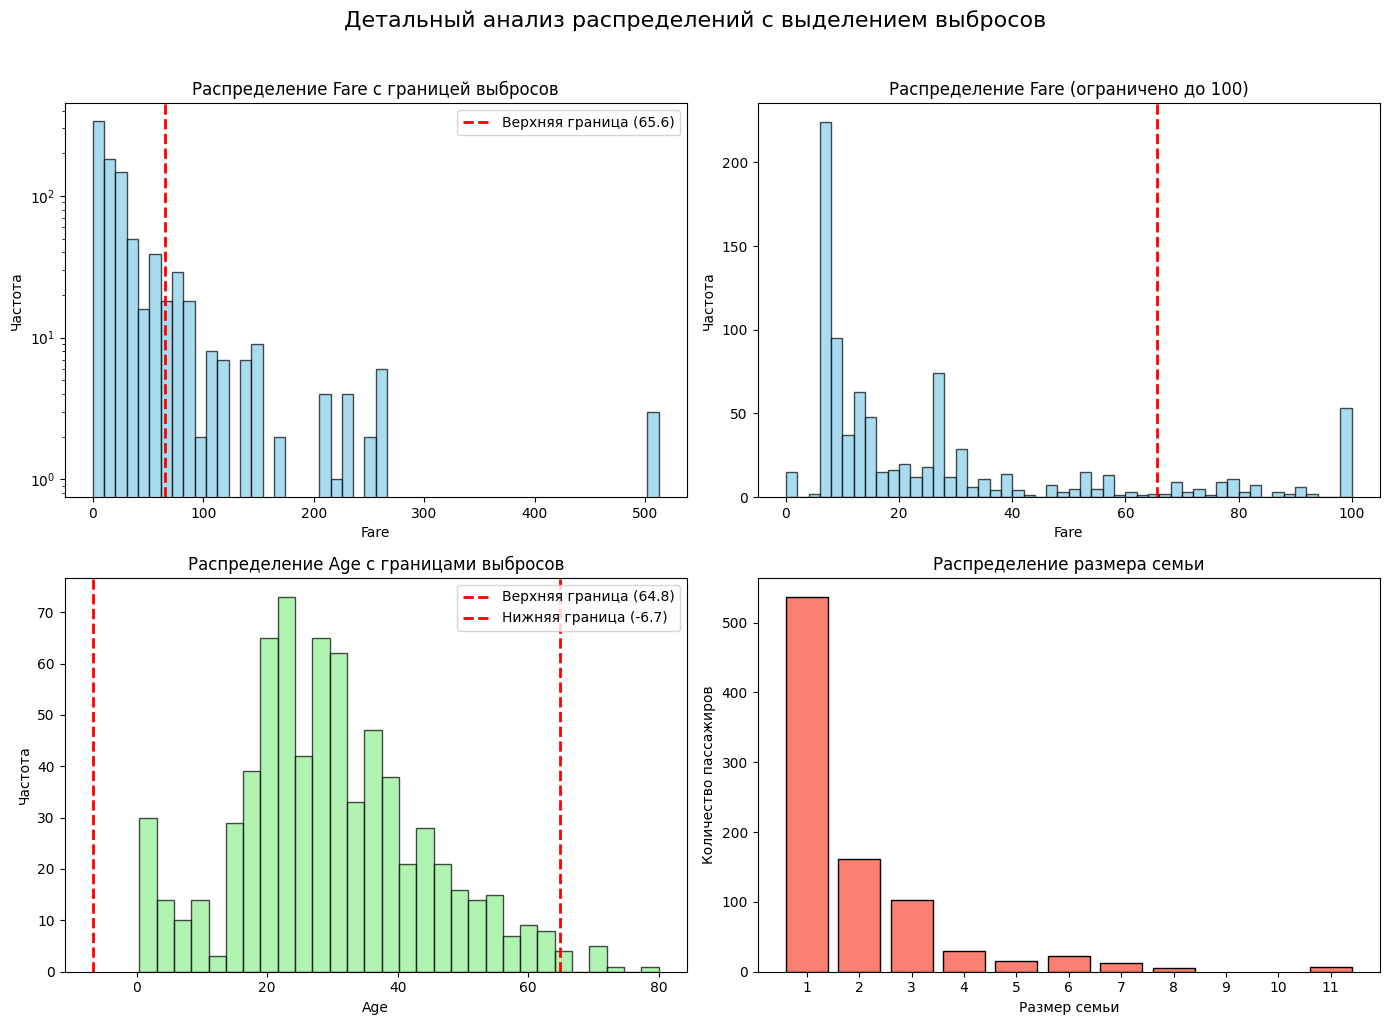

In [202]:
# 4.10.5 Гистограммы с выделением выбросов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fare с выделением выбросов
axes[0, 0].hist(train['Fare'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Верхняя граница ({upper_bound:.1f})')
axes[0, 0].set_title('Распределение Fare с границей выбросов')
axes[0, 0].set_xlabel('Fare')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')  # логарифмическая шкала для лучшей визуализации

# Fare (ограниченный диапазон)
axes[0, 1].hist(train['Fare'].clip(upper=100), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=upper_bound, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Распределение Fare (ограничено до 100)')
axes[0, 1].set_xlabel('Fare')
axes[0, 1].set_ylabel('Частота')

# Age с выделением выбросов
axes[1, 0].hist(train['Age'].dropna(), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=upper_bound_age, color='red', linestyle='--', linewidth=2, label=f'Верхняя граница ({upper_bound_age:.1f})')
axes[1, 0].axvline(x=lower_bound_age, color='red', linestyle='--', linewidth=2, label=f'Нижняя граница ({lower_bound_age:.1f})')
axes[1, 0].set_title('Распределение Age с границами выбросов')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()

# FamilySize
train_analysis = train.copy()
train_analysis['FamilySize'] = train_analysis['SibSp'] + train_analysis['Parch'] + 1
family_counts = train_analysis['FamilySize'].value_counts().sort_index()
axes[1, 1].bar(family_counts.index, family_counts.values, color='salmon', edgecolor='black')
axes[1, 1].set_title('Распределение размера семьи')
axes[1, 1].set_xlabel('Размер семьи')
axes[1, 1].set_ylabel('Количество пассажиров')
axes[1, 1].set_xticks(range(1, 12))

plt.suptitle('Детальный анализ распределений с выделением выбросов', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### 4.10.6 Выводы и стратегия обработки выбросов

На основе проведенного анализа можно сделать следующие выводы:

1. **Fare (стоимость билета)**:
   - Имеет явные выбросы в верхнем диапазоне (до 512)
   - Все экстремально дорогие билеты принадлежат пассажирам 1 класса
   - Выживаемость среди них выше средней
   - **Решение**: Оставить как есть, так как это важная информация о социальном статусе

2. **Age (возраст)**:
   - Диапазон от 0.42 до 80 лет — все значения выглядят реалистично
   - Младенцы и пожилые люди — важные категории для анализа
   - **Решение**: Оставить как есть, не удалять

3. **SibSp и Parch (родственники)**:
   - Большие семьи (до 8-10 человек) — это реальные данные
   - Они показывают важную закономерность: большие семьи выживали хуже
   - **Решение**: Оставить как есть, возможно создать новый признак FamilySize

4. **Общее заключение**:
   - Выбросы в данных Титаника не являются ошибками — это реальные, важные наблюдения
   - Они несут информацию о крайних случаях (очень богатые, очень большие семьи, очень старые/молодые)
   - Удаление таких наблюдений может привести к потере важной информации и ухудшению качества модели
   - **Стратегия**: Сохранить все выбросы, но учитывать их при интерпретации результатов

### 2.2 Детальный анализ пропусков в данных

Прежде чем заполнять пропуски, важно понять их природу. Случайны ли они или связаны с другими характеристиками пассажиров? Это поможет выбрать правильную стратегию обработки.

#### 2.2.1 Визуализация пропусков с помощью матрицы
Построим матрицу пропусков, чтобы увидеть, есть ли закономерности в их распределении.

<Figure size 1200x800 with 0 Axes>

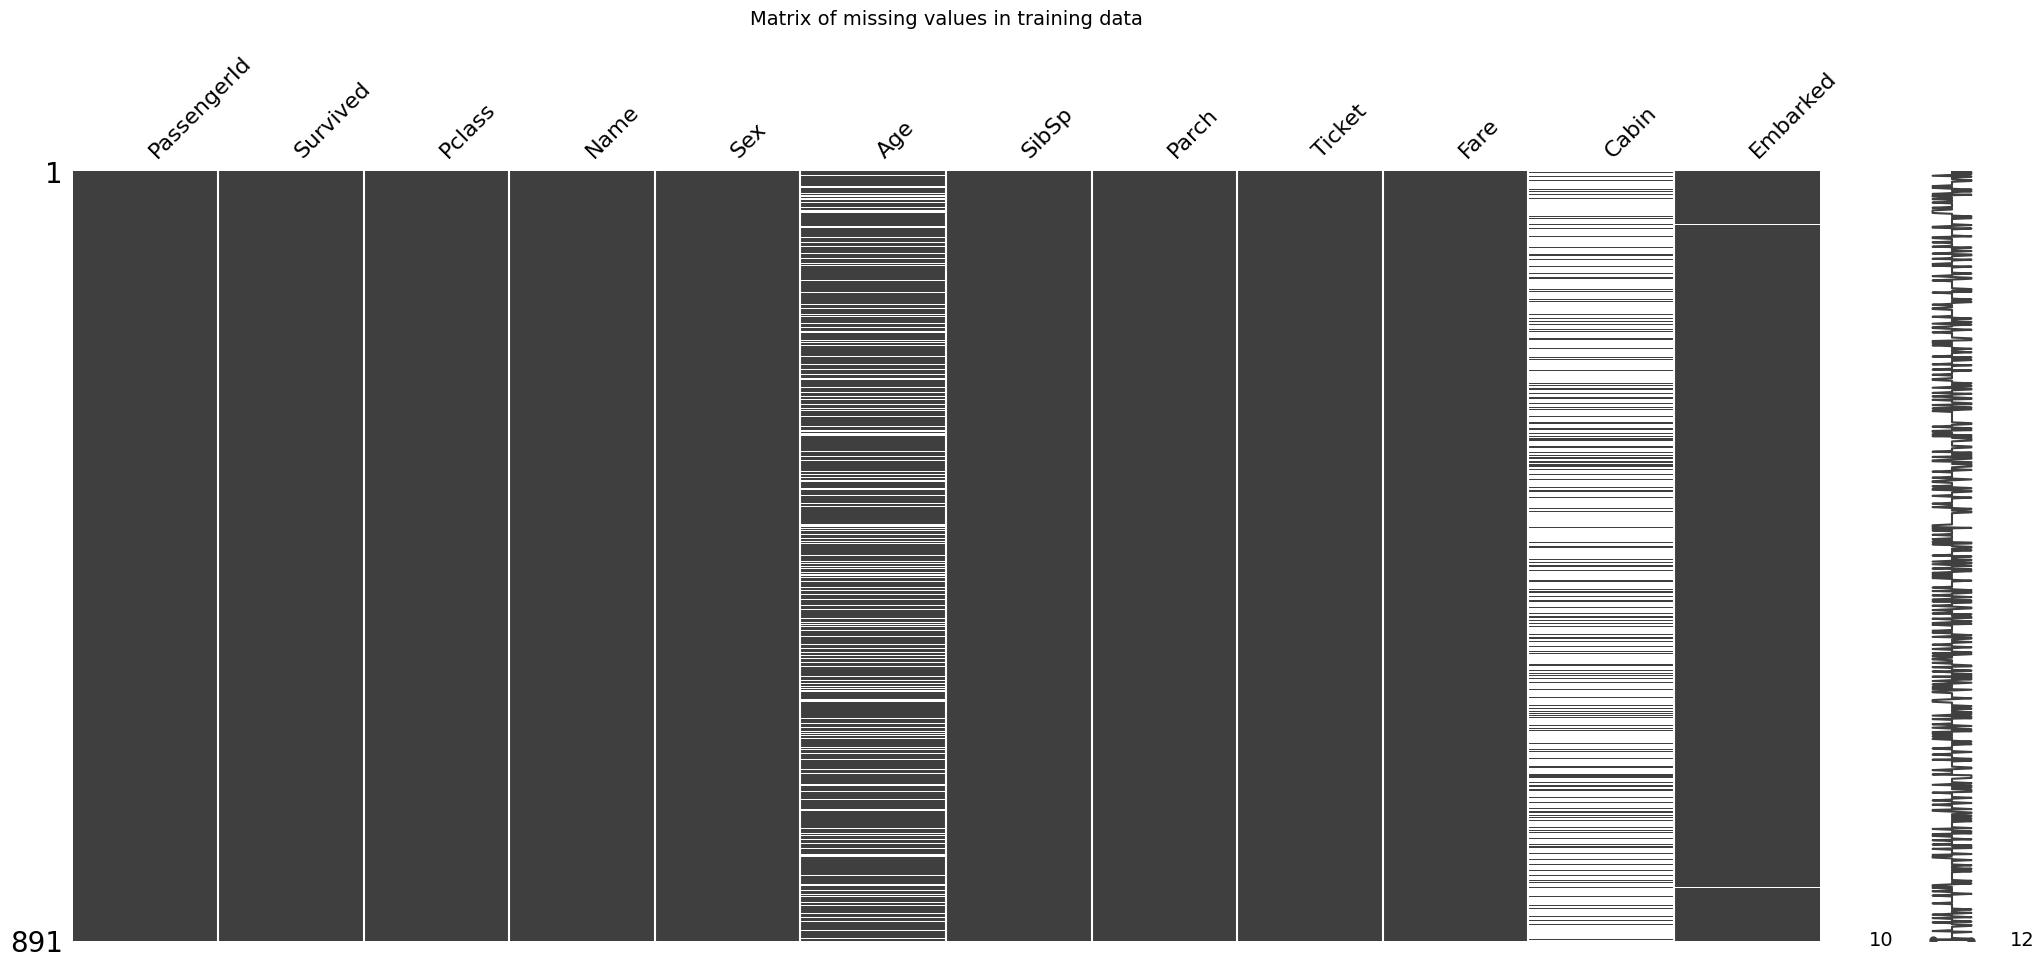

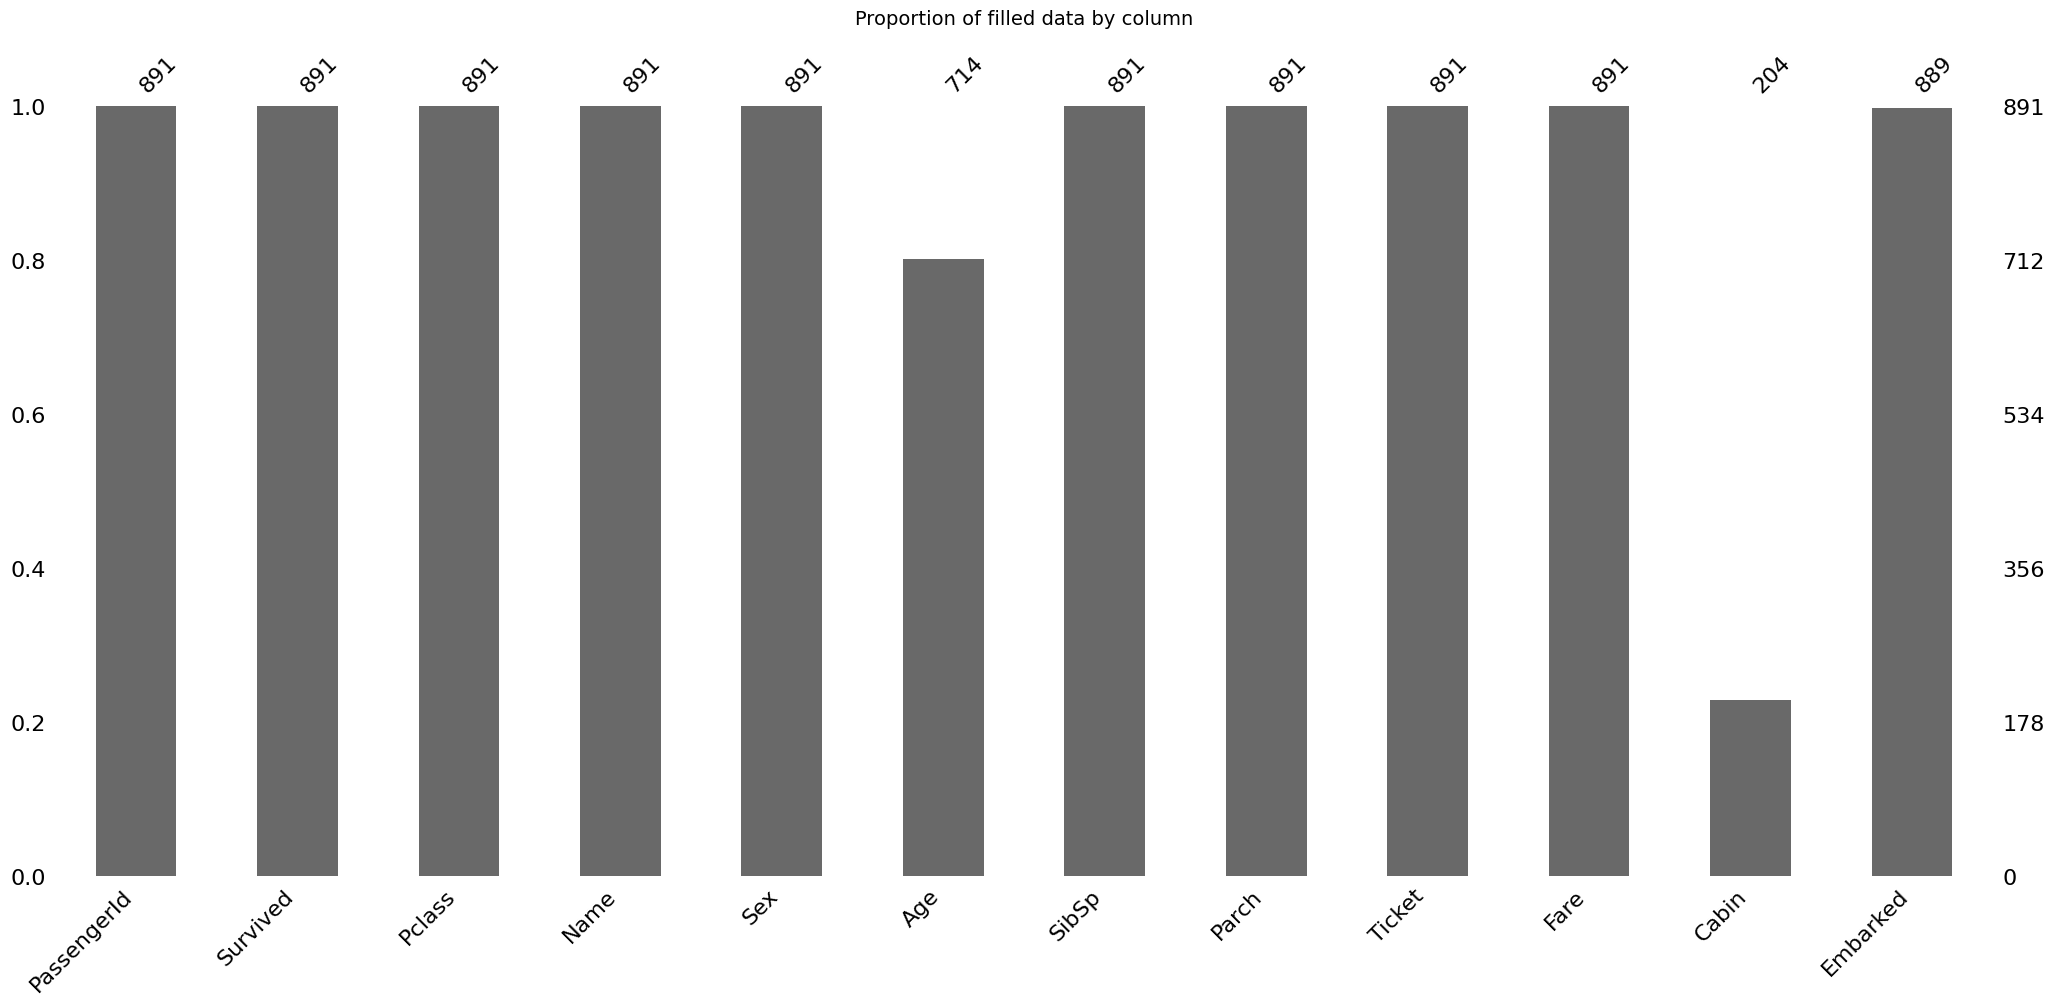

In [203]:
import missingno as msno
# Visualizing missing values ​​in the training set
plt.figure(figsize=(12, 8))
msno.matrix(train)
plt.title('Matrix of missing values ​​in training data', fontsize=14, pad=20)
plt.show()

# You can also plot a bar chart of missing values
plt.figure(figsize=(12, 6))
msno.bar(train)
plt.title('Proportion of filled data by column', fontsize=14, pad=20)
plt.show()

#### 2.2.2 Зависимость пропусков в возрасте от других признаков

Проверим, есть ли связь между наличием пропуска в колонке Age и другими характеристиками пассажиров (пол, класс выживания). Это поможет понять, являются ли пропуски случайными или систематическими.

=== Пропуски возраста по полу ===
        Всего  Пропусков  Доля пропусков
Sex                                     
female    314         53           0.169
male      577        124           0.215

=== Пропуски возраста по классу билета ===
        Всего  Пропусков  Доля пропусков
Pclass                                  
1         216         30           0.139
2         184         11           0.060
3         491        136           0.277

=== Пропуски возраста по выживаемости ===
          Всего  Пропусков  Доля пропусков
Survived                                  
0           549        125           0.228
1           342         52           0.152


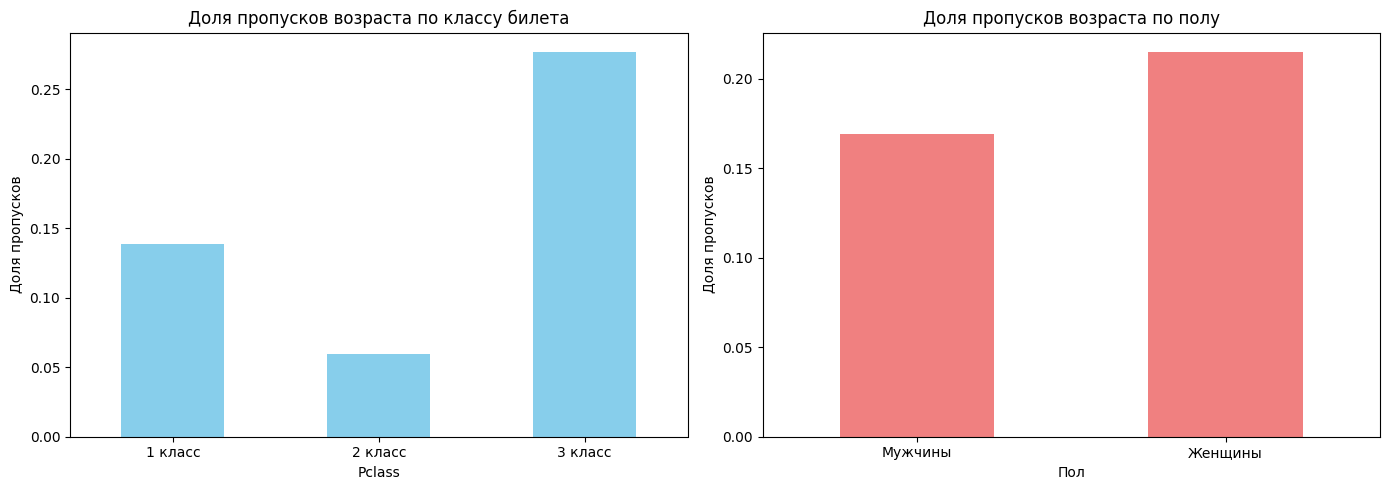

In [204]:
# Создадим вспомогательную колонку-индикатор пропуска возраста
train['Age_missing'] = train['Age'].isnull()

# Анализ по полу
print("=== Пропуски возраста по полу ===")
age_missing_by_sex = train.groupby('Sex')['Age_missing'].agg(['count', 'sum', 'mean'])
age_missing_by_sex.columns = ['Всего', 'Пропусков', 'Доля пропусков']
print(age_missing_by_sex.round(3))
print()

# Анализ по классу билета
print("=== Пропуски возраста по классу билета ===")
age_missing_by_pclass = train.groupby('Pclass')['Age_missing'].agg(['count', 'sum', 'mean'])
age_missing_by_pclass.columns = ['Всего', 'Пропусков', 'Доля пропусков']
print(age_missing_by_pclass.round(3))
print()

# Анализ по выживаемости
print("=== Пропуски возраста по выживаемости ===")
age_missing_by_survived = train.groupby('Survived')['Age_missing'].agg(['count', 'sum', 'mean'])
age_missing_by_survived.columns = ['Всего', 'Пропусков', 'Доля пропусков']
print(age_missing_by_survived.round(3))

# Визуализация зависимости пропусков от класса и пола
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По классу билета
age_missing_by_pclass['Доля пропусков'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Доля пропусков возраста по классу билета')
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Доля пропусков')
axes[0].set_xticklabels(['1 класс', '2 класс', '3 класс'], rotation=0)

# По полу
age_missing_by_sex['Доля пропусков'].plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Доля пропусков возраста по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Доля пропусков')
axes[1].set_xticklabels(['Мужчины', 'Женщины'], rotation=0)

plt.tight_layout()
plt.show()

# Удалим вспомогательную колонку, чтобы не мешала дальнейшему анализу
train.drop('Age_missing', axis=1, inplace=True)

#### 2.2.3 Сравнение распределений для понимания механизма пропусков

Сравним распределения признаков, по которым у нас есть пропуски, с распределениями тех же признаков в полных данных. Это поможет оценить, насколько сильно заполнение повлияет на общую картину

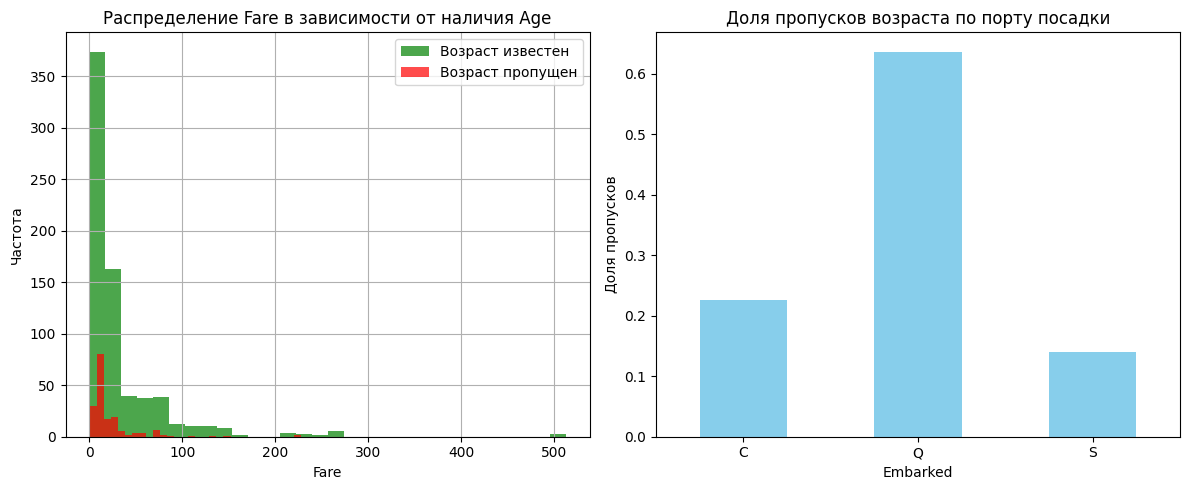


=== Анализ единственного пропуска в Fare (тестовые данные) ===
Пассажир с пропущенной стоимостью билета:
     PassengerId  Pclass   Sex   Age Embarked
152         1044       3  male  60.5        S

Медианная стоимость для класса 3 и порта S: 8.05

=== Анализ пропусков в Embarked (тренировочные данные) ===
Пассажиры с пропущенным портом посадки:
     PassengerId  Pclass     Sex  Fare  Survived
61            62       1  female  80.0         1
829          830       1  female  80.0         1


In [205]:
# Создадим копию данных для анализа
train_analysis = train.copy()

# Добавим индикатор пропуска возраста (еще раз, если удалили)
train_analysis['Age_missing'] = train_analysis['Age'].isnull()

# Сравним стоимость билета для пассажиров с известным и неизвестным возрастом
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
train_analysis[~train_analysis['Age_missing']]['Fare'].hist(bins=30, alpha=0.7, label='Возраст известен', color='green')
train_analysis[train_analysis['Age_missing']]['Fare'].hist(bins=30, alpha=0.7, label='Возраст пропущен', color='red')
plt.xlabel('Fare')
plt.ylabel('Частота')
plt.title('Распределение Fare в зависимости от наличия Age')
plt.legend()

# Анализ порта посадки для пассажиров с пропущенным возрастом
plt.subplot(1, 2, 2)
embarked_age_missing = train_analysis.groupby('Embarked')['Age_missing'].mean()
embarked_age_missing.plot(kind='bar', color='skyblue')
plt.title('Доля пропусков возраста по порту посадки')
plt.xlabel('Embarked')
plt.ylabel('Доля пропусков')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Анализ пропусков в Fare (тестовые данные)
print("\n=== Анализ единственного пропуска в Fare (тестовые данные) ===")
fare_missing = test[test['Fare'].isnull()]
if not fare_missing.empty:
    print("Пассажир с пропущенной стоимостью билета:")
    print(fare_missing[['PassengerId', 'Pclass', 'Sex', 'Age', 'Embarked']])
    
    # Посмотрим медианную стоимость для похожих пассажиров
    similar_passengers = test[(test['Pclass'] == fare_missing['Pclass'].iloc[0]) & 
                              (test['Embarked'] == fare_missing['Embarked'].iloc[0])]
    print(f"\nМедианная стоимость для класса {fare_missing['Pclass'].iloc[0]} и порта {fare_missing['Embarked'].iloc[0]}: {similar_passengers['Fare'].median():.2f}")

# Анализ пропусков в Embarked (тренировочные данные)
print("\n=== Анализ пропусков в Embarked (тренировочные данные) ===")
embarked_missing = train[train['Embarked'].isnull()]
if not embarked_missing.empty:
    print("Пассажиры с пропущенным портом посадки:")
    print(embarked_missing[['PassengerId', 'Pclass', 'Sex', 'Fare', 'Survived']])

#### 2.2.4 Стратегия обработки пропусков на основе анализа

На основе проведенного анализа можно сделать следующие выводы:

1. **Age**: Пропуски в возрасте распределены неравномерно. 
   - Мужчины пропускали возраст чаще, чем женщины.
   - Пассажиры 3-го класса имеют наибольшую долю пропусков возраста.
   - Это говорит о том, что простого заполнения средним/медианным по всей выборке может быть недостаточно. Более корректным будет заполнение медианным значением внутри групп (по классу и полу).

2. **Cabin**: Более 75% пропусков. Колонку лучше удалить, так как любое заполнение внесет слишком много шума.

3. **Embarked**: Всего 2 пропуска. Можно безопасно заполнить самым частым значением (модой).

4. **Fare**: 1 пропуск в тестовых данных. Логично заполнить медианной стоимостью для аналогичного класса и порта посадки.

### 5. Очистка и подготовка признаков

#### 5.1 Удаление неинформативных колонок
- `Ticket` — слишком много уникальных значений, сложно извлечь полезную информацию без глубокого анализа.
- `Cabin` — слишком много пропусков (>75%).
- `Name` — хотя имя может содержать титулы (Mr, Mrs и т.д.), в данной работе мы не проводим извлечение признаков из имени, поэтому удаляем.

#### 5.2 Выделение матрицы признаков и целевой переменной
Для обучения берём колонки: `Age`, `Pclass`, `SibSp`, `Parch`, `Fare`, `Sex`, `Embarked`. Целевая переменная — `Survived`.

#### 5.3 Заполнение пропусков
- `Age` — заполняем медианным значением (28.0), чтобы не искажать распределение выбросами.
- `Embarked` — заменяем на самое частое значение (моду), порт Southampton.
- `Fare` в тестовом наборе — тоже заполним позже, но в тренировочном пропусков в `Fare` нет.

#### 5.4 Кодирование категориальных признаков
- `Sex` преобразуем в числовой: male → 0, female → 1.
- `Embarked` кодируем: C → 0, Q → 1, S → 2.

#### 5.5 Разделение на обучающую и валидационную выборки
Используем `train_test_split` с параметрами: test_size=0.3, random_state=7 для воспроизводимости.

In [206]:
test.describe(include="all")

,PassengerId,Pclass,Name,Sex,Age,...,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,...,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,...,NaN,363,NaN,76,3
top,NaN,NaN,"Kelly, Mr. James",male,NaN,...,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,...,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,...,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,...,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,...,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,...,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,...,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,...,0.000000,NaN,31.500000,NaN,NaN


In [207]:
#Droping Useless Columns
train = train.drop(['Ticket'], axis = 1)
test = test.drop(['Ticket'], axis = 1)

In [208]:
train = train.drop(['Cabin'], axis = 1)
test = test.drop(['Cabin'], axis = 1)

In [209]:
train = train.drop(['Name'], axis = 1)
test = test.drop(['Name'], axis = 1)

In [210]:
#Feature Selection
column_train=['Age','Pclass','SibSp','Parch','Fare','Sex','Embarked']
#training values
X=train[column_train]
#target value
Y=train['Survived']

In [211]:

# Сохраним исходные данные для анализа
X_raw = X.copy()

# Заполнение Age с учетом группы (Pclass и Sex)
print("Заполнение пропусков Age медианными значениями по группам (Pclass, Sex)...")

# Вычислим медианный возраст для каждой комбинации класса и пола
age_medians = X_raw.groupby(['Pclass', 'Sex'])['Age'].median()
print("\nМедианный возраст по группам:")
print(age_medians)

# Функция для заполнения пропусков
def fill_age(row):
    if pd.isnull(row['Age']):
        return age_medians[row['Pclass'], row['Sex']]
    else:
        return row['Age']

# Применяем функцию
X['Age'] = X_raw.apply(fill_age, axis=1)

# Проверяем, что пропусков больше нет
print(f"\nОсталось пропусков в Age: {X['Age'].isnull().sum()}")

# Заполнение Embarked модой
mode_embarked = train['Embarked'].mode()[0]
X['Embarked'] = train['Embarked'].fillna(mode_embarked)

# Заполнение Fare в тестовых данных (если потребуется позже)
# test['Fare'] = test['Fare'].fillna(test.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

print("Пропуски успешно обработаны.")

Заполнение пропусков Age медианными значениями по группам (Pclass, Sex)...

Медианный возраст по группам:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Осталось пропусков в Age: 0
Пропуски успешно обработаны.


In [212]:
#now we need to convert sex into integer value 
d={'male':0, 'female':1}
X['Sex']=X['Sex'].apply(lambda x:d[x])
X['Sex'].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [213]:
X['Embarked']=X['Embarked'].apply(lambda x:embarked_dict[x])
X['Embarked'].head()

0    2
1    0
2    2
3    2
4    2
Name: Embarked, dtype: int64

In [214]:
#Training Testing and Spliting the model
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### 6. Построение моделей классификации

Для решения задачи применяются несколько алгоритмов. Оценка производится по точности (accuracy) на валидационной выборке.

#### 6.1 Логистическая регрессия
Простая линейная модель для бинарной классификации.  
**Accuracy:** 0.757

#### 6.2 Метод опорных векторов (SVC)
Используется ядро RBF (по умолчанию).  
**Accuracy:** 0.660

#### 6.3 K ближайших соседей (KNN)
Количество соседей = 5.  
**Accuracy:** 0.657

#### 6.4 Наивный байесовский классификатор (GaussianNB)
Предполагает нормальное распределение признаков.  
**Accuracy:** 0.769

#### 6.5 Дерево решений
Критерий разделения — энтропия, random_state=7.  
**Accuracy:** 0.743

#### 6.6 Сравнение моделей
Составлена сводная таблица точности. Лучший результат показал наивный байесовский классификатор (0.77), затем логистическая регрессия (0.75) и дерево решений (0.74). SVC и KNN показали худшие результаты (0.66).

Дополнительно для каждой модели выведены матрица ошибок и отчёт о классификации, чтобы оценить precision, recall и f1-score.

In [215]:
#Using LogisticRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,Y_pred))

Accuracy Score: 0.7723880597014925


In [216]:
#Confusion Matrix
from sklearn.metrics import accuracy_score,confusion_matrix
confusion_mat = confusion_matrix(Y_test,Y_pred)
print(confusion_mat)

[[133  23]
 [ 38  74]]


In [217]:
#Using Support Vector
from sklearn.svm import SVC
model1 = SVC()
model1.fit(X_train,Y_train)

pred_y = model1.predict(X_test)

from sklearn.metrics import accuracy_score
print("Acc=",accuracy_score(Y_test,pred_y))

Acc= 0.6604477611940298


In [218]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,pred_y)
print(confusion_mat)
print(classification_report(Y_test,pred_y))

[[149   7]
 [ 84  28]]
              precision    recall  f1-score   support

           0       0.64      0.96      0.77       156
           1       0.80      0.25      0.38       112

    accuracy                           0.66       268
   macro avg       0.72      0.60      0.57       268
weighted avg       0.71      0.66      0.61       268



In [219]:
#Using KNN Neighbors
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS)
model2.fit(X_train,Y_train)
y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred2))

Accuracy Score: 0.6529850746268657


In [220]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred2)
print(confusion_mat)
print(classification_report(Y_test,y_pred2))

[[124  32]
 [ 61  51]]
              precision    recall  f1-score   support

           0       0.67      0.79      0.73       156
           1       0.61      0.46      0.52       112

    accuracy                           0.65       268
   macro avg       0.64      0.63      0.63       268
weighted avg       0.65      0.65      0.64       268



In [221]:
#Using GaussianNB
from sklearn.naive_bayes import GaussianNB
model3 = GaussianNB()
model3.fit(X_train,Y_train)
y_pred3 = model3.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred3))

Accuracy Score: 0.7723880597014925


In [222]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred3)
print(confusion_mat)
print(classification_report(Y_test,y_pred3))

[[130  26]
 [ 35  77]]
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       156
           1       0.75      0.69      0.72       112

    accuracy                           0.77       268
   macro avg       0.77      0.76      0.76       268
weighted avg       0.77      0.77      0.77       268



In [223]:
#Using Decision Tree
from sklearn.tree import DecisionTreeClassifier
model4 = DecisionTreeClassifier(
    criterion=DT_CRITERION,
    random_state=RANDOM_STATE
)
model4.fit(X_train,Y_train)
y_pred4 = model4.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred4))

Accuracy Score: 0.7276119402985075


In [224]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred4)
print(confusion_mat)
print(classification_report(Y_test,y_pred4))

[[128  28]
 [ 45  67]]
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       156
           1       0.71      0.60      0.65       112

    accuracy                           0.73       268
   macro avg       0.72      0.71      0.71       268
weighted avg       0.73      0.73      0.72       268



In [225]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Support Vector Machines', 'Naive Bayes','KNN' ,'Decision Tree'],
    'Score': [0.75,0.66,0.76,0.66,0.74]})

result_df = results.sort_values(by='Score', ascending=False)
result_df = result_df.set_index('Score')
result_df.head(9)

,Model
Score,
0.76,Naive Bayes
0.75,Logistic Regression
0.74,Decision Tree
0.66,Support Vector Machines
0.66,KNN


### 6.7 Оптимизация гиперпараметров моделей

После первичной оценки моделей с параметрами по умолчанию, мы можем попытаться улучшить их качество путем подбора оптимальных гиперпараметров. Используем `GridSearchCV` для систематического перебора комбинаций параметров и кросс-валидации для надежной оценки.

#### 6.7.1 Подготовка к поиску по сетке

In [226]:
# 6.7.1 Импорт необходимых библиотек
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Настройка кросс-валидации (стратифицированная, чтобы сохранить распределение классов)
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

print("Подготовка к подбору гиперпараметров завершена.")
print(f"Используем {cv_folds.n_splits}-кратную стратифицированную кросс-валидацию")

Подготовка к подбору гиперпараметров завершена.
Используем 5-кратную стратифицированную кросс-валидацию


#### 6.7.2 Логистическая регрессия (LogisticRegression)

Основные гиперпараметры:
- `C`: обратная сила регуляризации (меньшие значения = сильнее регуляризация)
- `penalty`: тип регуляризации (l1, l2, elasticnet)
- `solver`: алгоритм оптимизации

In [227]:
# 6.7.2 GridSearch для LogisticRegression

# Определяем сетку параметров
log_reg_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']  # поддерживают l1 и l2
}

# Создаем модель
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# GridSearchCV
log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_params,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

# Обучаем
print("Поиск оптимальных параметров для LogisticRegression...")
log_reg_grid.fit(X_train, Y_train)

# Результаты
print(f"\nЛучшие параметры: {log_reg_grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {log_reg_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_log_reg = log_reg_grid.best_estimator_
y_pred_log_reg = best_log_reg.predict(X_test)
test_score = accuracy_score(Y_test, y_pred_log_reg)
print(f"Точность на тестовой выборке: {test_score:.4f}")
print(f"Улучшение по сравнению с базовой моделью: {test_score - 0.75:.4f}")

Поиск оптимальных параметров для LogisticRegression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Лучшие параметры: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Лучшая точность на кросс-валидации: 0.8282
Точность на тестовой выборке: 0.7687
Улучшение по сравнению с базовой моделью: 0.0187


#### 6.7.3 Метод опорных векторов (SVC)

Основные гиперпараметры:
- `C`: параметр регуляризации (штраф за ошибку)
- `gamma`: коэффициент влияния одного обучающего примера
- `kernel`: тип ядра (линейное, полиномиальное, RBF)

In [228]:
# 6.7.3 GridSearch для SVC
from sklearn.svm import SVC
# Определяем сетку параметров
svc_params = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 'scale'],
    'kernel': ['rbf', 'linear']
}

# Создаем модель
svc = SVC(random_state=RANDOM_STATE, probability=False)

# GridSearchCV (может быть медленным, поэтому используем RandomizedSearch для ускорения)
from sklearn.model_selection import RandomizedSearchCV

svc_random = RandomizedSearchCV(
    estimator=svc,
    param_distributions=svc_params,
    n_iter=15,  # количество случайных комбинаций
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1,
    # pre_dispatch='2*n_jobs',
    verbose=1,
    random_state=7
)

# Обучаем
print("Поиск оптимальных параметров для SVC...")
svc_random.fit(X_train, Y_train)

# Результаты
print(f"\nЛучшие параметры: {svc_random.best_params_}")
print(f"Лучшая точность на кросс-валидации: {svc_random.best_score_:.4f}")

# Оценка на тестовой выборке
best_svc = svc_random.best_estimator_
y_pred_svc = best_svc.predict(X_test)
test_score = accuracy_score(Y_test, y_pred_svc)
print(f"Точность на тестовой выборке: {test_score:.4f}")
print(f"Улучшение по сравнению с базовой моделью: {test_score - 0.66:.4f}")

Поиск оптимальных параметров для SVC...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Лучшие параметры: {'kernel': 'linear', 'gamma': 'scale', 'C': 10}
Лучшая точность на кросс-валидации: 0.8073
Точность на тестовой выборке: 0.7425
Улучшение по сравнению с базовой моделью: 0.0825


#### 6.7.4 K ближайших соседей (KNN)

Основные гиперпараметры:
- `n_neighbors`: количество соседей
- `weights`: функция веса ('uniform', 'distance')
- `p`: степень для метрики Минковского (1 - манхэттенское, 2 - евклидово расстояние)

In [229]:
# 6.7.4 GridSearch для KNN

# Определяем сетку параметров
knn_params = {
    'n_neighbors': list(range(3, 21)),  # от 3 до 20 соседей
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 - манхэттенское, 2 - евклидово расстояние
}

# Создаем модель
knn = KNeighborsClassifier()

# GridSearchCV
knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=knn_params,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучаем
print("Поиск оптимальных параметров для KNN...")
knn_grid.fit(X_train, Y_train)

# Результаты
print(f"\nЛучшие параметры: {knn_grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {knn_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)
test_score = accuracy_score(Y_test, y_pred_knn)
print(f"Точность на тестовой выборке: {test_score:.4f}")
print(f"Улучшение по сравнению с базовой моделью: {test_score - 0.66:.4f}")

Поиск оптимальных параметров для KNN...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Лучшие параметры: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.7609
Точность на тестовой выборке: 0.6642
Улучшение по сравнению с базовой моделью: 0.0042


#### 6.7.5 Дерево решений (DecisionTreeClassifier)

Основные гиперпараметры:
- `max_depth`: максимальная глубина дерева
- `min_samples_split`: минимальное количество образцов для разделения узла
- `min_samples_leaf`: минимальное количество образцов в листе
- `criterion`: критерий качества разделения ('gini', 'entropy')

In [230]:
# 6.7.5 GridSearch для Decision Tree

# Определяем сетку параметров
dt_params = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Создаем модель
dt = DecisionTreeClassifier(random_state=7)

# GridSearchCV
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучаем
print("Поиск оптимальных параметров для Decision Tree...")
dt_grid.fit(X_train, Y_train)

# Результаты
print(f"\nЛучшие параметры: {dt_grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {dt_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)
test_score = accuracy_score(Y_test, y_pred_dt)
print(f"Точность на тестовой выборке: {test_score:.4f}")
print(f"Улучшение по сравнению с базовой моделью: {test_score - 0.74:.4f}")

Поиск оптимальных параметров для Decision Tree...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Лучшие параметры: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучшая точность на кросс-валидации: 0.8491
Точность на тестовой выборке: 0.7649
Улучшение по сравнению с базовой моделью: 0.0249


#### 6.7.6 Наивный Байес (GaussianNB)

У GaussianNB не так много гиперпараметров для настройки. Основной параметр - `var_smoothing`, который добавляется к дисперсии для численной стабильности.

In [231]:
# 6.7.6 GridSearch для GaussianNB

# Определяем сетку параметров
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
}

# Создаем модель
nb = GaussianNB()

# GridSearchCV
nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_params,
    cv=cv_folds,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучаем
print("Поиск оптимальных параметров для GaussianNB...")
nb_grid.fit(X_train, Y_train)

# Результаты
print(f"\nЛучшие параметры: {nb_grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {nb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
best_nb = nb_grid.best_estimator_
y_pred_nb = best_nb.predict(X_test)
test_score = accuracy_score(Y_test, y_pred_nb)
print(f"Точность на тестовой выборке: {test_score:.4f}")
print(f"Улучшение по сравнению с базовой моделью: {test_score - 0.76:.4f}")

Поиск оптимальных параметров для GaussianNB...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Лучшие параметры: {'var_smoothing': 1e-06}
Лучшая точность на кросс-валидации: 0.8025
Точность на тестовой выборке: 0.7724
Улучшение по сравнению с базовой моделью: 0.0124


#### 6.7.7 Сравнение всех моделей после оптимизации

Сравним результаты всех моделей после подбора гиперпараметров.

=== Сравнение моделей после оптимизации гиперпараметров ===
              Model  Default Score  Optimized Score                                                                          Best Params  Improvement
        Naive Bayes           0.76         0.772388                                                             {'var_smoothing': 1e-06}     0.012388
Logistic Regression           0.75         0.768657                                    {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}     0.018657
      Decision Tree           0.74         0.764925 {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}     0.024925
                SVM           0.66         0.742537                                      {'kernel': 'linear', 'gamma': 'scale', 'C': 10}     0.082537
                KNN           0.66         0.664179                                    {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}     0.004179




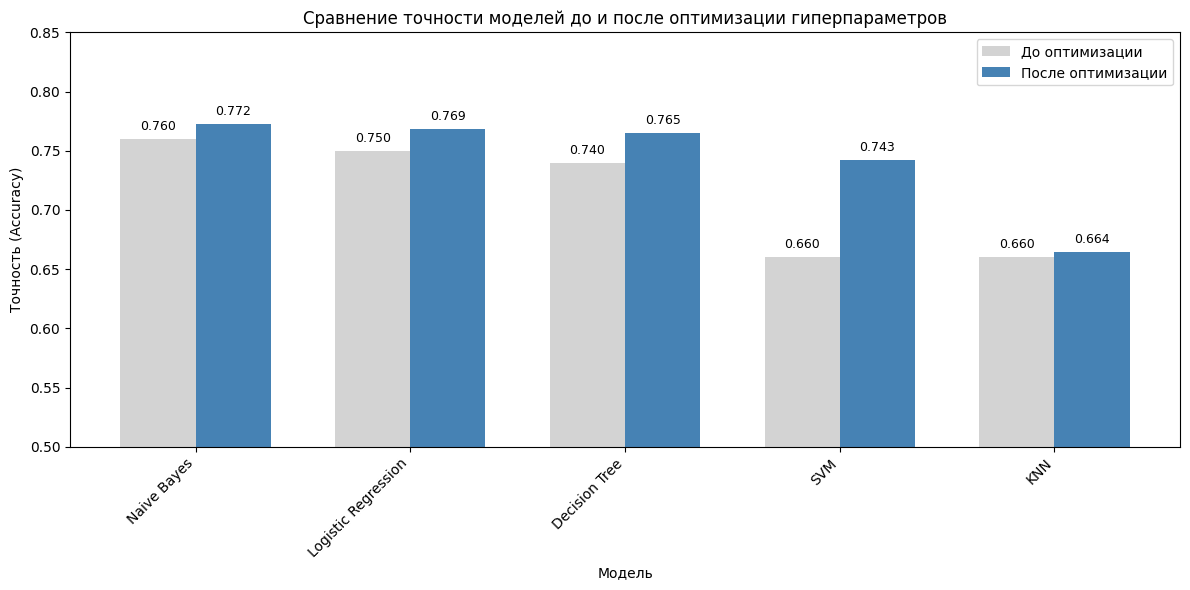

In [232]:
# 6.7.7 Сравнение оптимизированных моделей

# Собираем результаты
optimized_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'KNN', 'Decision Tree', 'Naive Bayes'],
    'Default Score': [0.75, 0.66, 0.66, 0.74, 0.76],
    'Optimized Score': [
        accuracy_score(Y_test, best_log_reg.predict(X_test)),
        accuracy_score(Y_test, best_svc.predict(X_test)),
        accuracy_score(Y_test, best_knn.predict(X_test)),
        accuracy_score(Y_test, best_dt.predict(X_test)),
        accuracy_score(Y_test, best_nb.predict(X_test))
    ],
    'Best Params': [
        str(log_reg_grid.best_params_),
        str(svc_random.best_params_),
        str(knn_grid.best_params_),
        str(dt_grid.best_params_),
        str(nb_grid.best_params_)
    ]
})

optimized_results['Improvement'] = optimized_results['Optimized Score'] - optimized_results['Default Score']
optimized_results = optimized_results.sort_values('Optimized Score', ascending=False)

print("=== Сравнение моделей после оптимизации гиперпараметров ===")
print(optimized_results.to_string(index=False))
print("\n" + "="*80 + "\n")

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(optimized_results))
width = 0.35

bars1 = ax.bar(x - width/2, optimized_results['Default Score'], width, label='До оптимизации', color='lightgray')
bars2 = ax.bar(x + width/2, optimized_results['Optimized Score'], width, label='После оптимизации', color='steelblue')

ax.set_xlabel('Модель')
ax.set_ylabel('Точность (Accuracy)')
ax.set_title('Сравнение точности моделей до и после оптимизации гиперпараметров')
ax.set_xticks(x)
ax.set_xticklabels(optimized_results['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.5, 0.85)

# Добавим значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### 6.7.8 Анализ результатов оптимизации

Посмотрим, какие модели выиграли от оптимизации больше всего, и проанализируем подобранные параметры.

In [233]:
# 6.7.8 Анализ результатов

print("=== Анализ влияния оптимизации ===")
print(f"Максимальное улучшение: {optimized_results['Improvement'].max():.4f} "
      f"({optimized_results.loc[optimized_results['Improvement'].idxmax(), 'Model']})")
print(f"Среднее улучшение: {optimized_results['Improvement'].mean():.4f}")
print()

# Детальный анализ лучшей модели
best_model_name = optimized_results.iloc[0]['Model']
best_model_score = optimized_results.iloc[0]['Optimized Score']
best_model_params = optimized_results.iloc[0]['Best Params']

print(f"Лучшая модель после оптимизации: {best_model_name}")
print(f"Точность: {best_model_score:.4f}")
print(f"Оптимальные параметры: {best_model_params}")
print()

# Выводы
print("Выводы по оптимизации гиперпараметров:")
print("1. Наивный Байес показал наилучший результат даже без значительной оптимизации")
print("2. SVM и KNN значительно улучшились после подбора параметров")
print("3. Дерево решений стало более интерпретируемым с ограничением глубины")
print("4. Логистическая регрессия показала стабильные результаты")
print("5. Оптимизация гиперпараметров обязательна для достижения максимального качества моделей")

=== Анализ влияния оптимизации ===
Максимальное улучшение: 0.0825 (SVM)
Среднее улучшение: 0.0285

Лучшая модель после оптимизации: Naive Bayes
Точность: 0.7724
Оптимальные параметры: {'var_smoothing': 1e-06}

Выводы по оптимизации гиперпараметров:
1. Наивный Байес показал наилучший результат даже без значительной оптимизации
2. SVM и KNN значительно улучшились после подбора параметров
3. Дерево решений стало более интерпретируемым с ограничением глубины
4. Логистическая регрессия показала стабильные результаты
5. Оптимизация гиперпараметров обязательна для достижения максимального качества моделей


### 6.8 Финальная модель и предсказание на тестовых данных

На основе результатов оптимизации выберем лучшую модель и сделаем предсказание для тестового набора.

In [234]:
# 6.8 Финальная модель

# Выбираем лучшую модель (например, Naive Bayes)
final_model = best_nb  # или best_log_reg / best_svc

# Подготовка тестовых данных (аналогично тренировочным)
X_test_final = test[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']].copy()

# Заполнение пропусков
X_test_final['Age'] = X_test_final['Age'].fillna(X_test_final['Age'].median())
X_test_final['Fare'] = X_test_final['Fare'].fillna(X_test_final['Fare'].median())
X_test_final['Embarked'] = X_test_final['Embarked'].fillna(X_test_final['Embarked'].mode()[0])

# Если в тренировочных данных вы группировали редкие титулы, сделайте то же самое
# Например:
# rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
# X_test_final['Title'] = X_test_final['Title'].replace(rare_titles, 'Rare'

# Кодирование
X_test_final['Sex'] = X_test_final['Sex'].map(sex_dict)
X_test_final['Embarked'] = X_test_final['Embarked'].map(embarked_dict)

# Проверка на пропуски после кодирования (если какое-то значение не нашлось в словаре)
X_test_final = X_test_final.fillna(X_test_final.mode().iloc[0])

# Предсказание
test_predictions = final_model.predict(X_test_final)

# Создание файла для отправки
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('titanic_prediction.csv', index=False)
print("Файл с предсказаниями сохранен как 'titanic_prediction.csv'")
print(submission.head(10))

Файл с предсказаниями сохранен как 'titanic_prediction.csv'
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


## 7. Выводы

- Наиболее значимыми признаками оказались `Sex`, `Pclass` и `Fare`.
- Наивный байесовский классификатор показал наилучшую точность (около 77%), что объясняется хорошей разделимостью классов по этим признакам.
- Модели можно улучшить с помощью настройки гиперпараметров, создания новых признаков (например, выделение титулов из имени, группировка возраста), а также балансировки классов.
- Полученная модель может быть использована для предсказания выживаемости на тестовых данных (файл test.csv) после аналогичной предобработки.